# TESI DI LAUREA 
## Cavallari Anna

## EDA & Preprocessing 

Questo notebook illustra un flusso completo di **Exploratory Data Analysis (EDA)** e **preprocessing** sul dataset COMPAS.

### Struttura del notebook
1. set up e caricamento iniziare dei dati
2. prima esplorazione dei dataset
3. controllo duplicati
4. selezione variabili utili
5. gestione valori mancanti
6. filtro ProPubblica
EDA
7. Analisi esplorativa variabili numeriche
    7.1 boxplot outlier
8. Analisi esplorativa variabili categoriche
9. Ricerca categorie rare
10. rilevamento outlier
11. Analisi delle correlazioni
12. EDA per variabile target
13. relazione variabile target e altre variabili
    13.1 categoriche
    13.2 numeriche
14. analisi variabile target e variabili sensibili race e sex
15. analisi score compas e gruppi sensibili race e sex
16. riassunto finale

## 1. Setup e caricamento iniziale dei dati

In [79]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


DOWNLOAD DATASET COMPAS

In [80]:
import os
import pandas as pd

file_path = "ds/compas-scores-two-years (1).csv"

df_raw = pd.read_csv(file_path)

print(f"Dataset caricato: {df_raw.shape[0]:,} righe × {df_raw.shape[1]} colonne")
df_raw.head()

Dataset caricato: 7,214 righe × 53 colonne


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


Subito dopo viene stampata la dimensione del dataset, cioè:

- numero di righe
- numero di colonne

e viene visualizzata un’anteprima delle prime osservazioni.

piccolo check

In [81]:
df_raw.shape
df_raw.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='str')

- quante osservazioni sono presenti
- quali variabili sono disponibili

___
## 2. Prima esplorazione del dataset

In [82]:
df_raw.info()
df_raw.describe()


<class 'pandas.DataFrame'>
RangeIndex: 7214 entries, 0 to 7213
Data columns (total 53 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       7214 non-null   int64  
 1   name                     7214 non-null   str    
 2   first                    7214 non-null   str    
 3   last                     7214 non-null   str    
 4   compas_screening_date    7214 non-null   str    
 5   sex                      7214 non-null   str    
 6   dob                      7214 non-null   str    
 7   age                      7214 non-null   int64  
 8   age_cat                  7214 non-null   str    
 9   race                     7214 non-null   str    
 10  juv_fel_count            7214 non-null   int64  
 11  decile_score             7214 non-null   int64  
 12  juv_misd_count           7214 non-null   int64  
 13  juv_other_count          7214 non-null   int64  
 14  priors_count             7214 non-n

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,7192.000,7214.000,2316.000,0.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000,7214.000
mean,5501.256,34.818,0.067,4.510,0.091,0.109,3.472,3.305,57.731,0.481,20.269,NaN,0.114,4.510,3.692,3.472,11.465,553.437,0.383,0.451
std,3175.707,11.889,0.474,2.856,0.485,0.502,4.883,75.810,329.740,0.500,74.872,NaN,0.317,2.856,2.510,4.883,46.955,399.021,0.486,0.498
min,1.000,18.000,0.000,1.000,0.000,0.000,0.000,-414.000,0.000,0.000,-1.000,NaN,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000
25%,2735.250,25.000,0.000,2.000,0.000,0.000,0.000,-1.000,1.000,0.000,0.000,NaN,0.000,2.000,1.000,0.000,0.000,148.250,0.000,0.000
50%,5509.500,31.000,0.000,4.000,0.000,0.000,2.000,-1.000,1.000,0.000,0.000,NaN,0.000,4.000,3.000,2.000,0.000,530.500,0.000,0.000
75%,8246.500,42.000,0.000,7.000,0.000,0.000,5.000,0.000,2.000,1.000,1.000,NaN,0.000,7.000,5.000,5.000,1.000,914.000,1.000,1.000
max,11001.000,96.000,20.000,10.000,13.000,17.000,38.000,1057.000,9485.000,1.000,993.000,NaN,1.000,10.000,10.000,38.000,937.000,1186.000,1.000,1.000


Con info() si osserva:

- se una colonna è numerica o categorica
- quante osservazioni non nulle ha
- se ci sono possibili problemi di formattazione

Con describe() si osservano per le variabili numeriche:

- media
- deviazione standard
- minimi e massimi
- quartili

In [83]:
df_raw.describe(include="all")


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
count,7214.000,7214,7214,7214,7214,7214,7214,7214.000,7214,7214,7214.000,7214.000,7214.000,7214.000,7214.000,6907.000,6907,6907,7192,6055,1137,7192.000,7214,7185,7214.000,3471,3471,2316.000,3471,3413,2316,2316,0.000,7214.000,819,819,819,819,7214,7214.000,7214,7214,7214,7214.000,7214,7214,6978,6978,7214.000,7214.000,7214.000,7214.000,7214.000
unique,NaN,7158,2800,3950,690,2,5452,NaN,3,6,NaN,NaN,NaN,NaN,NaN,NaN,6907,6880,7192,927,580,NaN,2,437,NaN,3471,10,NaN,1075,340,972,938,NaN,NaN,819,9,570,83,1,NaN,3,690,1,NaN,3,690,1156,1169,NaN,NaN,NaN,NaN,NaN
top,NaN,anthony smith,michael,williams,2013-02-20,Male,1989-04-27,NaN,25 - 45,African-American,NaN,NaN,NaN,NaN,NaN,NaN,2013-08-13 06:03:42,2013-09-28 02:10:00,13011352CF10A,2013-02-22,2013-02-06,NaN,F,Battery,NaN,13009779CF10A,(M1),NaN,2014-12-08,Driving License Suspended,2014-05-27,2014-12-09,NaN,NaN,13009779CF10A,(M1),2015-08-15,Battery,Risk of Recidivism,NaN,Low,2013-02-20,Risk of Violence,NaN,Low,2013-02-20,2014-01-22,2020-01-01,NaN,NaN,NaN,NaN,NaN
freq,NaN,3,149,83,32,5819,5,NaN,4109,3696,NaN,NaN,NaN,NaN,NaN,NaN,1,3,1,26,9,NaN,4666,1156,NaN,1,1201,NaN,12,258,9,9,NaN,NaN,1,344,6,329,7214,NaN,3897,32,7214,NaN,4761,32,20,61,NaN,NaN,NaN,NaN,NaN
mean,5501.256,NaN,NaN,NaN,NaN,NaN,NaN,34.818,NaN,NaN,0.067,4.510,0.091,0.109,3.472,3.305,NaN,NaN,NaN,NaN,NaN,57.731,NaN,NaN,0.481,NaN,NaN,20.269,NaN,NaN,NaN,NaN,NaN,0.114,NaN,NaN,NaN,NaN,NaN,4.510,NaN,NaN,NaN,3.692,NaN,NaN,NaN,NaN,3.472,11.465,553.437,0.383,0.451
std,3175.707,NaN,NaN,NaN,NaN,NaN,NaN,11.889,NaN,NaN,0.474,2.856,0.485,0.502,4.883,75.810,NaN,NaN,NaN,NaN,NaN,329.740,NaN,NaN,0.500,NaN,NaN,74.872,NaN,NaN,NaN,NaN,NaN,0.317,NaN,NaN,NaN,NaN,NaN,2.856,NaN,NaN,NaN,2.510,NaN,NaN,NaN,NaN,4.883,46.955,399.021,0.486,0.498
min,1.000,NaN,NaN,NaN,NaN,NaN,NaN,18.000,NaN,NaN,0.000,1.000,0.000,0.000,0.000,-414.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,-1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,0.000,0.000,0.000
25%,2735.250,NaN,NaN,NaN,NaN,NaN,NaN,25.000,NaN,NaN,0.000,2.000,0.000,0.000,0.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,NaN,1.000,NaN,NaN,NaN,NaN,0.000,0.000,148.250,0.000,0.000
50%,5509.500,NaN,NaN,NaN,NaN,NaN,NaN,31.000,NaN,NaN,0.000,4.000,0.000,0.000,2.000,-1.000,NaN,NaN,NaN,NaN,NaN,1.000,NaN,NaN,0.000,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,4.000,NaN,NaN,NaN,3.000,NaN,NaN,NaN,NaN,2.000,0.000,530.500,0.000,0.000
75%,8246.500,NaN,NaN,NaN,NaN,NaN,NaN,42.000,NaN,NaN,0.000,7.000,0.000,0.000,5.000,0.000,NaN,NaN,NaN,NaN,NaN,2.000,NaN,NaN,1.000,NaN,NaN,1.000,NaN,NaN,NaN,NaN,NaN,0.000,NaN,NaN,NaN,NaN,NaN,7.000,NaN,NaN,NaN,5.000,NaN,NaN,NaN,NaN,5.000,1.000,914.000,1.000,1.000


Con describe(include="all") si estende l’analisi anche alle categoriche:

- numero di valori osservati
- categoria più frequente
- frequenza della modalità

In [84]:
df_raw.isnull().sum().sort_values(ascending=False)


violent_recid              7214
vr_charge_degree           6395
vr_case_number             6395
vr_offense_date            6395
vr_charge_desc             6395
c_arrest_date              6077
r_jail_out                 4898
r_jail_in                  4898
r_days_from_arrest         4898
r_charge_desc              3801
r_offense_date             3743
r_case_number              3743
r_charge_degree            3743
c_offense_date             1159
c_jail_out                  307
days_b_screening_arrest     307
c_jail_in                   307
out_custody                 236
in_custody                  236
c_charge_desc                29
c_days_from_compas           22
c_case_number                22
v_type_of_assessment          0
type_of_assessment            0
decile_score.1                0
v_decile_score                0
v_score_text                  0
v_screening_date              0
screening_date                0
priors_count.1                0
start                         0
end     

Con isnull().sum() viene controllata la presenza di missing values in ciascuna colonna. in ordine ascendente ossia dal più alto al nullo

mostrare che ho analizzato la struttura del dataset prima della pulizia.

In [85]:
df_raw.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.000,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.000,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.000,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.000,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.000,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.000,F,Possession of Cocaine,1,13011511MM10A,(M1),0.000,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.000,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,0,1,0,0,0,0.000,2013-11-30 04:50:18,2013-12-01 12:28:56,13022355MM10A,2013-11-30,NaN,0.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-11-30,Risk of Violence,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,0,6,0,0,14,-1.000,2014-02-18 05:08:24,2014-02-24 12:18:30,14002304CF10A,2014-02-18,NaN,1.000,F,Possession Burglary Tools,1,14004485CF10A,(F2),0.000,2014-03-31,Poss of Firearm by Convic Felo,2014-03-31,2014-04-18,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,6,Medium,2014-02-19,Risk of Violence,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,0,4,0,0,3,-1.000,2013-08-29 08:55:23,2013-08-30 08:42:13,13012216CF10A,NaN,2013-08-29,1.000,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-08-30,Risk of Violence,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,0,1,0,0,0,-1.000,2014-03-15 05:35:34,2014-03-18 04:28:46,14004524MM10A,2014-03-15,NaN,1.000,M,Battery,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2014-03-16,Risk of Violence,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,brada

___
## 3. controllo duplicati

In [86]:
df_nodup = df_raw.drop_duplicates().copy()

before = len(df_raw)
after = len(df_nodup)

print(f"Duplicati rimossi: {before - after} righe")
print(f"Shape dopo rimozione duplicati: {df_nodup.shape}")


Duplicati rimossi: 0 righe
Shape dopo rimozione duplicati: (7214, 53)


Questo passaggio serve a evitare che eventuali osservazioni ripetute influenzino in modo scorretto l’analisi descrittiva e le analisi successive.
La rimozione dei duplicati migliora la qualità del dataset perché evita di sovrarappresentare alcuni casi.

___
## 4.selezioni varibili utili

In [87]:
cols = [
    "age",
    "age_cat",
    "sex",
    "race",
    "priors_count",
    "days_b_screening_arrest",
    "c_charge_degree",
    "is_recid",
    "score_text",
    "decile_score",
    "two_year_recid"
]

df_selected = df_nodup[cols].copy()

Qui si riduce il dataset alle sole variabili utili all’analisi della tesi, eliminando colonne non centrali rispetto al tema della recidiva e del bias algoritmico.

In [88]:
print("Shape dataset selezionato:", df_selected.shape)
print("\nColonne del dataset selezionato:")
display(pd.DataFrame({"colonne": df_selected.columns}))

Shape dataset selezionato: (7214, 11)

Colonne del dataset selezionato:


,colonne
0,age
1,age_cat
2,sex
3,race
4,priors_count
5,days_b_screening_arrest
6,c_charge_degree
7,is_recid
8,score_text
9,decile_score


Serve a confermare che:

- la riduzione delle variabili sia avvenuta correttamente
- il dataset finale per l’analisi contenga solo gli attributi scelti

___
## 5. gestione valori mancanti

In [89]:
missing_selected = pd.DataFrame({
    "count": df_selected.isnull().sum(),
    "percent": df_selected.isnull().mean() * 100
}).query("count > 0").sort_values("percent", ascending=False)

missing_selected

,count,percent
days_b_screening_arrest,307,4.256


Questo passaggio serve a valutare se nelle variabili selezionate siano presenti problemi di completezza che potrebbero alterare l’analisi.

In altre parole, è una verifica della qualità dei dati limitata al sottoinsieme effettivamente usato nella tesi.

____
## 6. Filtro ProPubblica

In [90]:
df_filtered = df_selected[
    (df_selected["days_b_screening_arrest"] <= 30) &
    (df_selected["days_b_screening_arrest"] >= -30) &
    (df_selected["is_recid"] != -1) &
    (df_selected["c_charge_degree"] != "O") &
    (df_selected["score_text"] != "N/A")
].copy()

print("Shape dopo filtro ProPublica:", df_filtered.shape)

Shape dopo filtro ProPublica: (6172, 11)


Il dataset viene filtrato secondo i criteri usati da ProPublica nel famoso lavoro di analisi del caso COMPAS. In particolare vengono mantenute solo le osservazioni che rispettano queste condizioni:

a) days_b_screening_arrest compreso tra -30 e +30

Vengono esclusi i casi in cui la differenza tra screening e arresto è troppo ampia.

b) is_recid != -1

Si eliminano i casi con codifica anomala o non interpretabile rispetto alla recidiva.

c) c_charge_degree != "O"

Si escludono le osservazioni con una tipologia di accusa non rilevante o non coerente con l’analisi standard.

d) score_text != "N/A"

Si eliminano i casi in cui il sistema non ha assegnato una classificazione interpretabile del rischio.

In [91]:
df_filtered.isnull().sum()

age                        0
age_cat                    0
sex                        0
race                       0
priors_count               0
days_b_screening_arrest    0
c_charge_degree            0
is_recid                   0
score_text                 0
decile_score               0
two_year_recid             0
dtype: int64

In [92]:
df_filtered.shape

(6172, 11)

controllo ulteriore di eventuali valori residui

# EDA

___
## 7. Analisi esplorativa variabili numeriche

In [93]:
num_cols_main = ['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']
bin_cols = ['is_recid', 'two_year_recid']

print('=== VARIABILI NUMERICHE PRINCIPALI ===')
display(
    df_filtered[num_cols_main].describe().T.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .highlight_min('mean', color='lightcoral')
)

print('=== VARIABILI BINARIE ===')
display(
    df_filtered[bin_cols].describe().T.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .highlight_min('mean', color='lightcoral')
)

=== VARIABILI NUMERICHE PRINCIPALI ===


,count,mean,std,min,25%,50%,75%,max
age,6172.000000,34.534511,11.730938,18.000000,25.000000,31.000000,42.000000,96.000000
priors_count,6172.000000,3.246436,4.743770,0.000000,0.000000,1.000000,4.000000,38.000000
days_b_screening_arrest,6172.000000,-1.740279,5.084709,-30.000000,-1.000000,-1.000000,-1.000000,30.000000
decile_score,6172.000000,4.418503,2.839463,1.000000,2.000000,4.000000,7.000000,10.000000


=== VARIABILI BINARIE ===


,count,mean,std,min,25%,50%,75%,max
is_recid,6172.000000,0.484446,0.499799,0.000000,0.000000,0.000000,1.000000,1.000000
two_year_recid,6172.000000,0.455120,0.498022,0.000000,0.000000,0.000000,1.000000,1.000000


Per ciascuna variabile numerica si osservano:

- conteggio
- media
- deviazione standard
- minimo
- quartili
- massimo

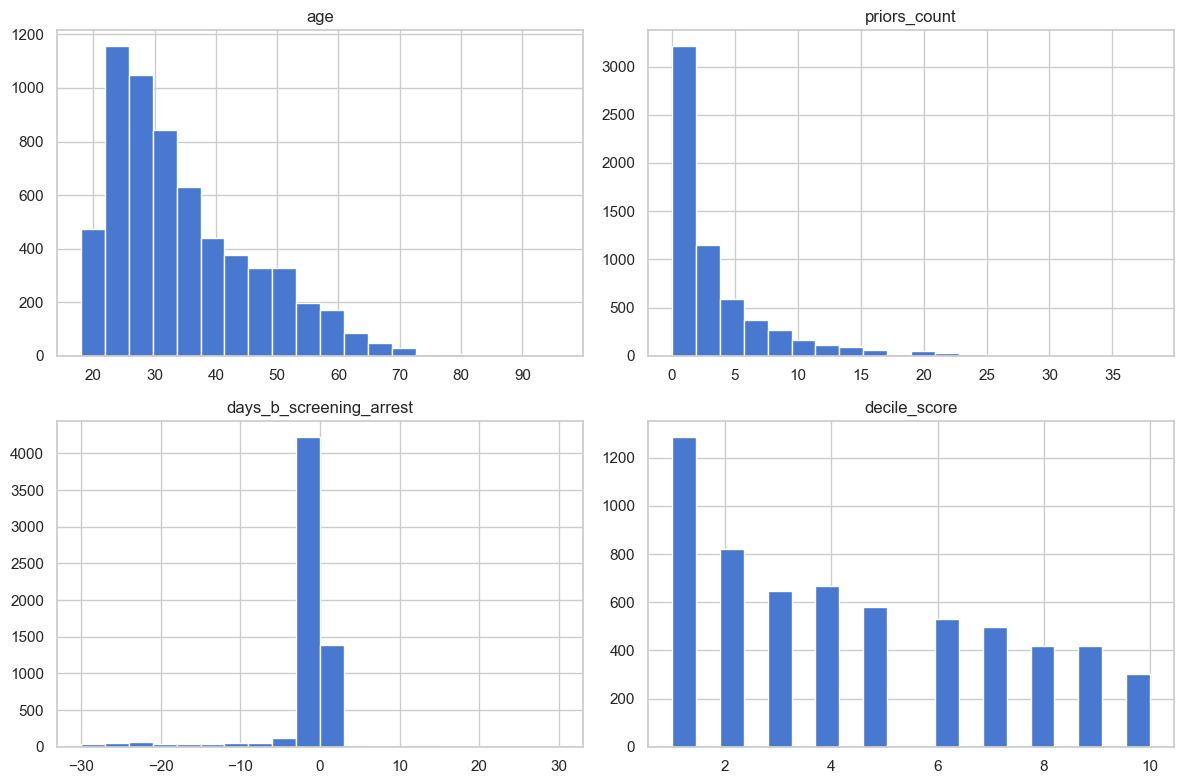

In [94]:
num_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

df_filtered[num_cols].hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

### 7.1 Boxplot outlier

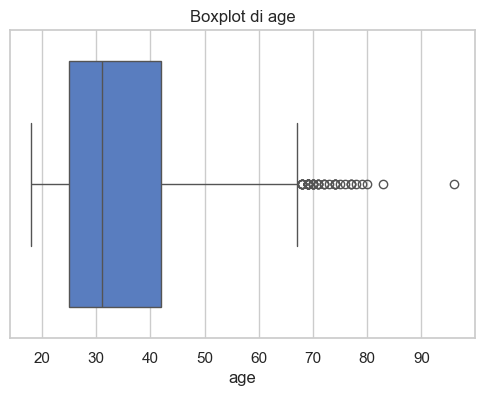

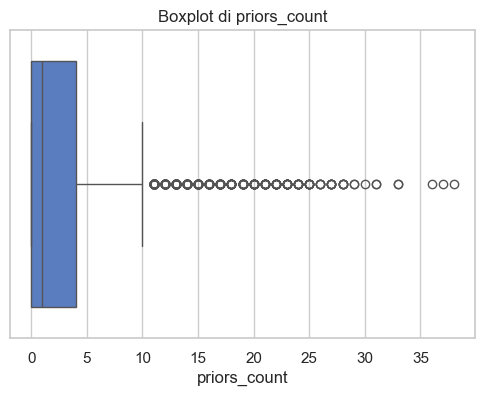

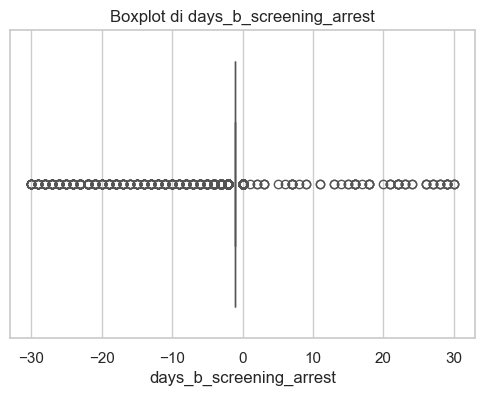

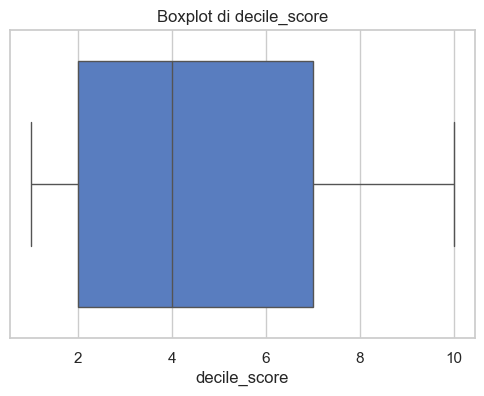

In [95]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df_filtered[col])
    plt.title(f"Boxplot di {col}")
    plt.show()

___
## 8. Analisi esplorativa variabili categoriche

In [96]:
print('=== CATEGORICHE ===')
df_filtered.describe(include=['object', 'string'])

=== CATEGORICHE ===


,age_cat,sex,race,c_charge_degree,score_text
count,6172,6172,6172,6172,6172
unique,3,2,6,2,3
top,25 - 45,Male,African-American,F,Low
freq,3532,4997,3175,3970,3421


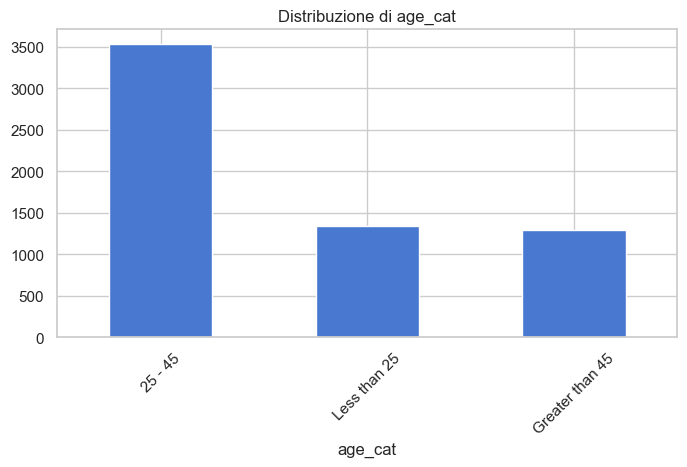

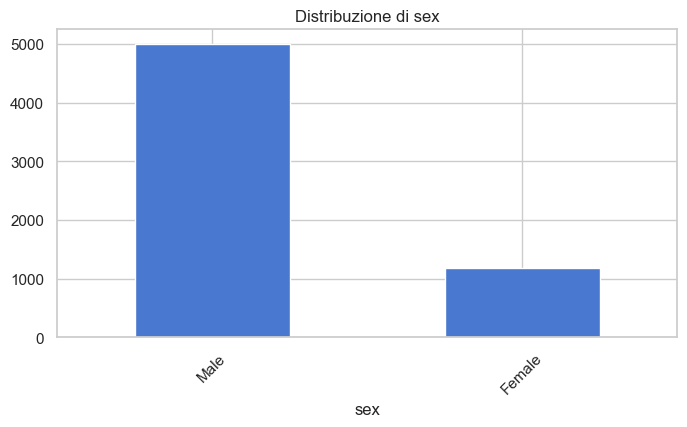

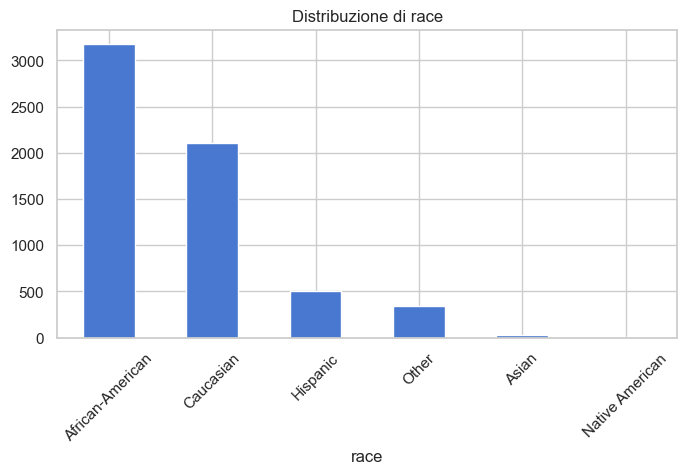

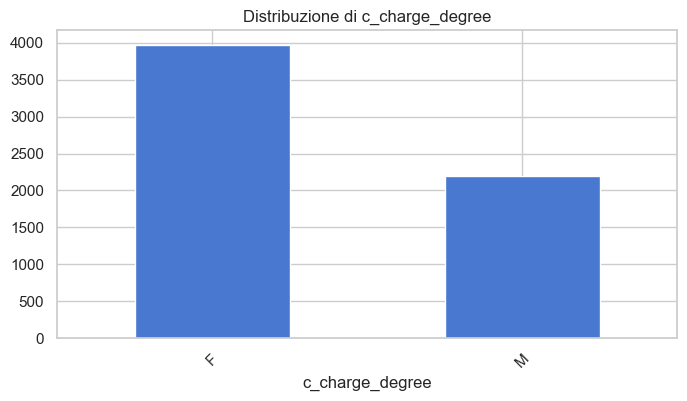

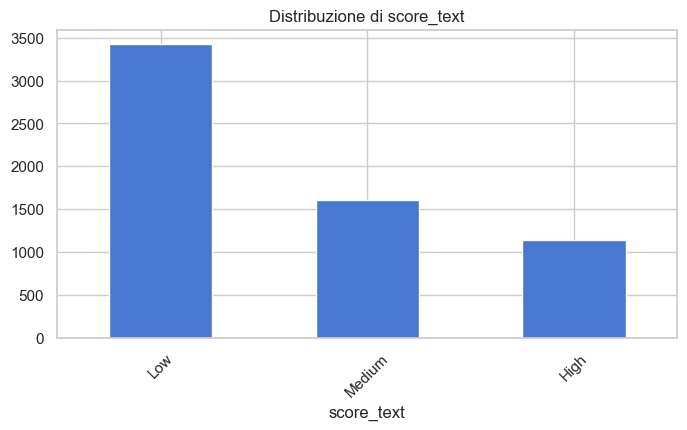

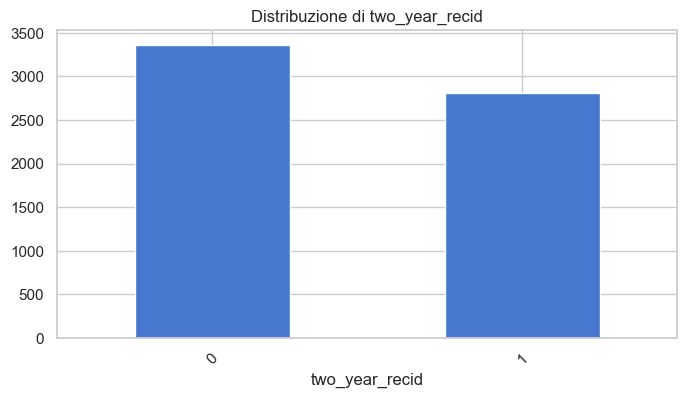

In [97]:
cat_cols = ["age_cat", "sex", "race", "c_charge_degree", "score_text", "two_year_recid"]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    df_filtered[col].value_counts(dropna=False).plot(kind="bar")
    plt.title(f"Distribuzione di {col}")
    plt.xticks(rotation=45)
    plt.show()

In [98]:
cat_cols = ["age_cat", "sex", "race", "c_charge_degree", "score_text"]

for col in cat_cols:
    print(f"\n===== {col} =====")
    print("Frequenze assolute:")
    print(df_filtered[col].value_counts(dropna=False))
    print("\nFrequenze percentuali:")
    print(round(df_filtered[col].value_counts(normalize=True, dropna=False) * 100, 2))


===== age_cat =====
Frequenze assolute:
age_cat
25 - 45            3532
Less than 25       1347
Greater than 45    1293
Name: count, dtype: int64

Frequenze percentuali:
age_cat
25 - 45           57.230
Less than 25      21.820
Greater than 45   20.950
Name: proportion, dtype: float64

===== sex =====
Frequenze assolute:
sex
Male      4997
Female    1175
Name: count, dtype: int64

Frequenze percentuali:
sex
Male     80.960
Female   19.040
Name: proportion, dtype: float64

===== race =====
Frequenze assolute:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Asian                 31
Native American       11
Name: count, dtype: int64

Frequenze percentuali:
race
African-American   51.440
Caucasian          34.070
Hispanic            8.250
Other               5.560
Asian               0.500
Native American     0.180
Name: proportion, dtype: float64

===== c_charge_degree =====
Frequenze assolute:
c_charge_degree
F    3970
M    2202
N

controllo cardinalità

In [99]:
# Cardinalità (numero di valori unici) per ogni colonna categorica
cardinality = df_filtered[cat_cols].nunique().sort_values(ascending=False)
print('Cardinalità colonne categoriche:')
display(cardinality.to_frame('n_unique'))

Cardinalità colonne categoriche:


,n_unique
race,6
age_cat,3
score_text,3
sex,2
c_charge_degree,2


- quante modalità distinte ha ogni variabile
- se vi sono colonne con cardinalità eccessiva
- se alcune variabili richiederebbero una ricodifica

___
## 9. Ricerca delle categorie rare

In [100]:
threshold = 0.01

for col in cat_cols:
    freq = df_filtered[col].value_counts(normalize=True, dropna=False)
    rare_categories = freq[freq < threshold]

    print(f"\nCategorie rare in {col} (meno dell'1%):")
    print(rare_categories if not rare_categories.empty else "Nessuna categoria rara")


Categorie rare in age_cat (meno dell'1%):
Nessuna categoria rara

Categorie rare in sex (meno dell'1%):
Nessuna categoria rara

Categorie rare in race (meno dell'1%):
race
Asian             0.005
Native American   0.002
Name: proportion, dtype: float64

Categorie rare in c_charge_degree (meno dell'1%):
Nessuna categoria rara

Categorie rare in score_text (meno dell'1%):
Nessuna categoria rara


Viene impostata una soglia del 1% e per ogni colonna categorica vengono individuate le categorie con frequenza inferiore a quella soglia.

In [101]:
threshold = 0.01

for col in cat_cols:
    freq_rel = df_filtered[col].value_counts(normalize=True, dropna=False)
    rare_labels = freq_rel[freq_rel < threshold].index

    freq_abs = df_filtered[col].value_counts(dropna=False)
    rare_counts = freq_abs.loc[rare_labels]

    print(f"\nCategorie rare in {col} (meno dell'1%):")
    print(rare_counts if not rare_counts.empty else "Nessuna categoria rara")


Categorie rare in age_cat (meno dell'1%):
Nessuna categoria rara

Categorie rare in sex (meno dell'1%):
Nessuna categoria rara

Categorie rare in race (meno dell'1%):
race
Asian              31
Native American    11
Name: count, dtype: int64

Categorie rare in c_charge_degree (meno dell'1%):
Nessuna categoria rara

Categorie rare in score_text (meno dell'1%):
Nessuna categoria rara


In [102]:
df_filtered.shape

(6172, 11)

___
## 10. Rilevamente outlier

In [103]:
def detect_outliers_iqr(df, cols, k=1.5):
   
    results = []
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - k * IQR, Q3 + k * IQR
        n_out = ((df[col] < lower) | (df[col] > upper)).sum()
        results.append({
            'colonna': col,
            'lower_bound': lower,
            'upper_bound': upper,
            'n_outliers': n_out,
            'pct_outliers': n_out / len(df) * 100
        })
    return pd.DataFrame(results).sort_values('pct_outliers', ascending=False)

outlier_report = detect_outliers_iqr(df_filtered, num_cols)
display(outlier_report.style.bar(subset=['pct_outliers'], color='#f4a261').format({'pct_outliers': '{:.2f}%'}))

,colonna,lower_bound,upper_bound,n_outliers,pct_outliers
2,days_b_screening_arrest,-1.000000,-1.000000,2192,35.52%
1,priors_count,-6.000000,10.000000,492,7.97%
0,age,-0.500000,67.500000,51,0.83%
3,decile_score,-5.500000,14.500000,0,0.00%


Per ogni variabile numerica la funzione stabilisce quali valori si trovano fuori dall’intervallo

Gli outlier vengono rilevati ma non rimossi automaticamente, poiché nel contesto giudiziario valori estremi possono rappresentare casi reali e informativamente rilevanti. La loro presenza viene quindi documentata e discussa, senza alterare il dataset finale destinato alle analisi successive.

___
## 11. Analisi delle correlazioni

In [104]:
corr_cols = [
    "age",
    "priors_count",
    "days_b_screening_arrest",
    "decile_score",
    "two_year_recid"
]

corr_matrix = df_filtered[corr_cols].corr(method="spearman")

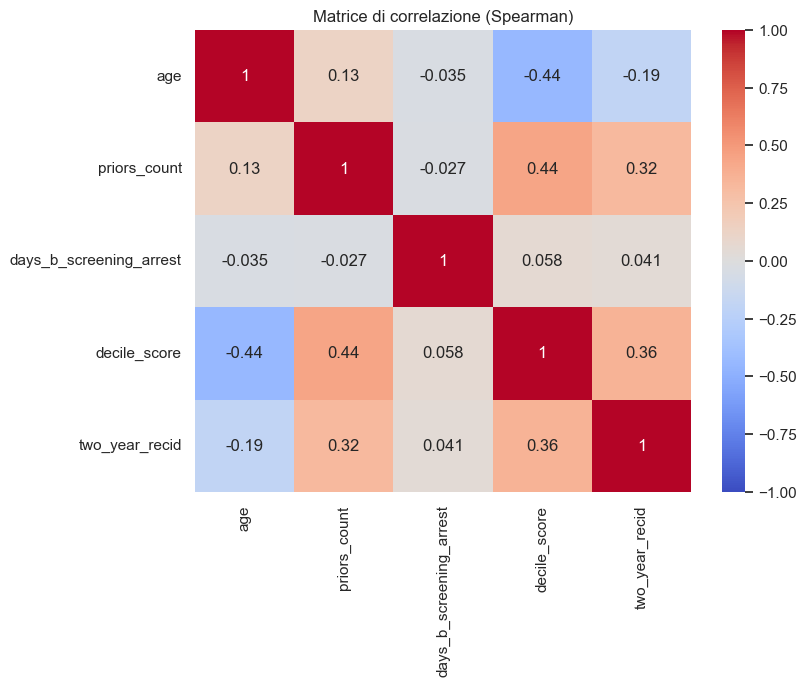

In [105]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Matrice di correlazione (Spearman)")
plt.show()

In [106]:
corr_pairs = (
    corr_matrix.where(np.tril(np.ones(corr_matrix.shape), k=-1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlazione"]
corr_pairs["abs_corr"] = corr_pairs["correlazione"].abs()

corr_pairs.sort_values("abs_corr", ascending=False).head(10)

,feature_1,feature_2,correlazione,abs_corr
15,decile_score,age,-0.442,0.442
16,decile_score,priors_count,0.440,0.440
23,two_year_recid,decile_score,0.365,0.365
21,two_year_recid,priors_count,0.321,0.321
20,two_year_recid,age,-0.190,0.190
5,priors_count,age,0.128,0.128
17,decile_score,days_b_screening_arrest,0.058,0.058
22,two_year_recid,days_b_screening_arrest,0.041,0.041
10,days_b_screening_arrest,age,-0.035,0.035
11,days_b_screening_arrest,priors_count,-0.027,0.027


___
## 12. EDA per la varibile target

,two_year_recid,count,percent
0,0,3363,54.490
1,1,2809,45.510


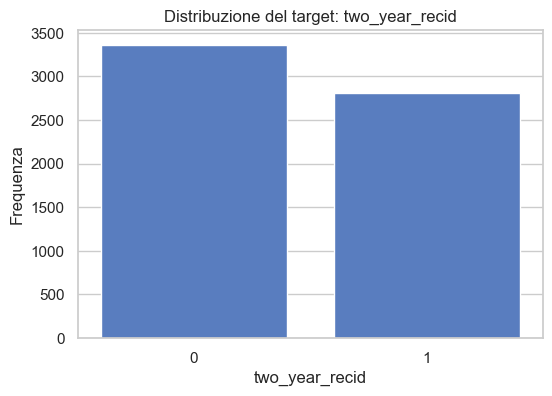

In [107]:
target_dist = (
    df_filtered["two_year_recid"]
    .value_counts(dropna=False)
    .rename_axis("two_year_recid")
    .reset_index(name="count")
)
target_dist["percent"] = (target_dist["count"] / len(df_filtered) * 100).round(2)

display(target_dist)

plt.figure(figsize=(6,4))
sns.countplot(data=df_filtered, x="two_year_recid")
plt.title("Distribuzione del target: two_year_recid")
plt.xlabel("two_year_recid")
plt.ylabel("Frequenza")
plt.show()

___
## 13. Relazione variabile target e altre varibili

### 13.1 categoriche

Cosa mostra

Questa sezione consente di vedere come varia la quota di recidiva a seconda della categoria considerata.

two_year_recid,0,1
race,,
African-American,47.690,52.310
Asian,74.190,25.810
Caucasian,60.910,39.090
Hispanic,62.870,37.130
Native American,54.550,45.450
Other,63.850,36.150


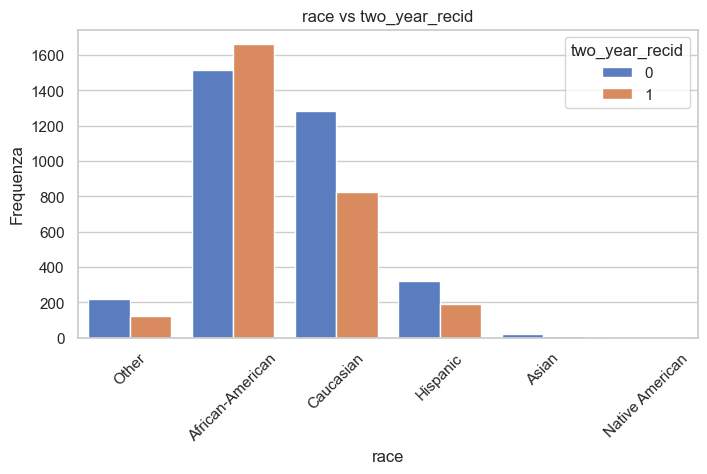

two_year_recid,0,1
sex,,
Female,64.850,35.150
Male,52.050,47.950


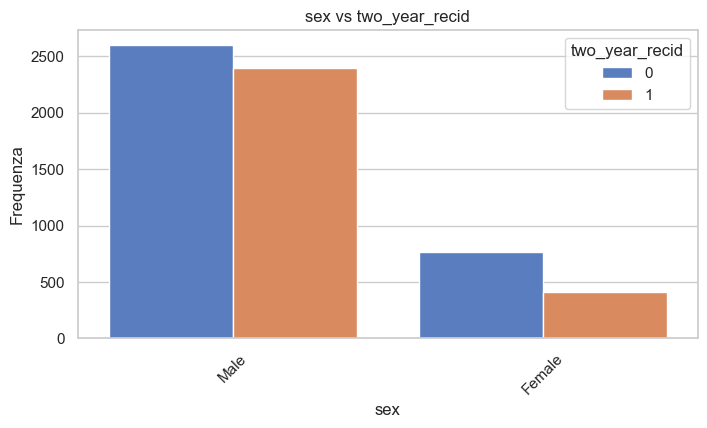

two_year_recid,0,1
age_cat,,
25 - 45,53.540,46.460
Greater than 45,67.980,32.020
Less than 25,44.020,55.980


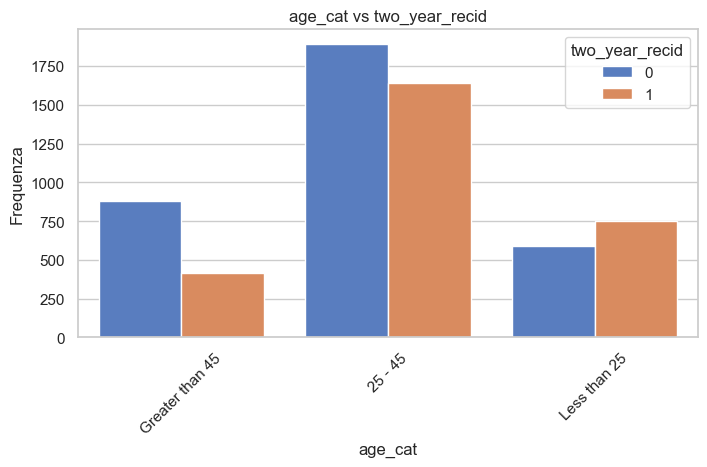

two_year_recid,0,1
c_charge_degree,,
F,50.030,49.970
M,62.530,37.470


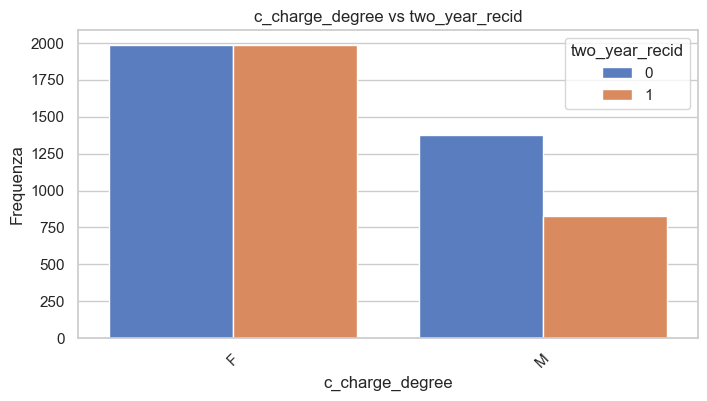

two_year_recid,0,1
score_text,,
High,25.960,74.040
Low,68.550,31.450
Medium,44.870,55.130


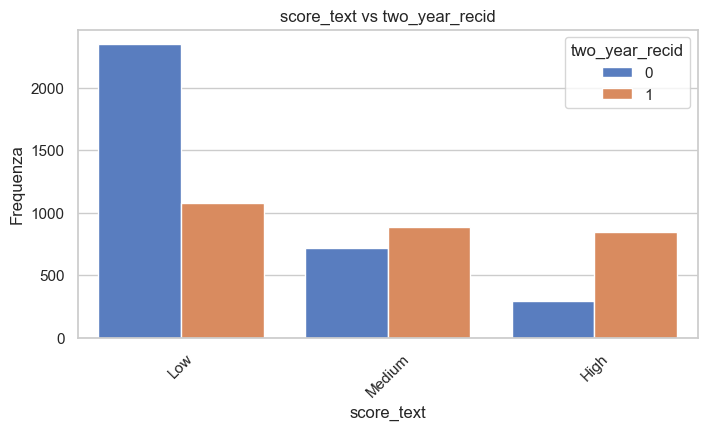

In [108]:
eda_cat_cols = ["race", "sex", "age_cat", "c_charge_degree", "score_text"]

for col in eda_cat_cols:
    summary = pd.crosstab(df_filtered[col], df_filtered["two_year_recid"], normalize="index") * 100
    display(summary.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_filtered, x=col, hue="two_year_recid")
    plt.title(f"{col} vs two_year_recid")
    plt.xticks(rotation=45)
    plt.ylabel("Frequenza")
    plt.show()

### 13.2 numeriche

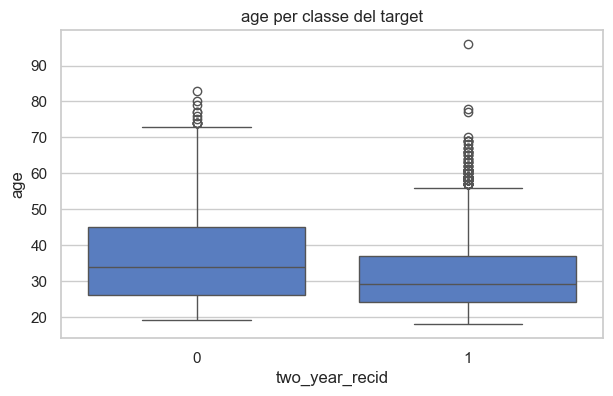

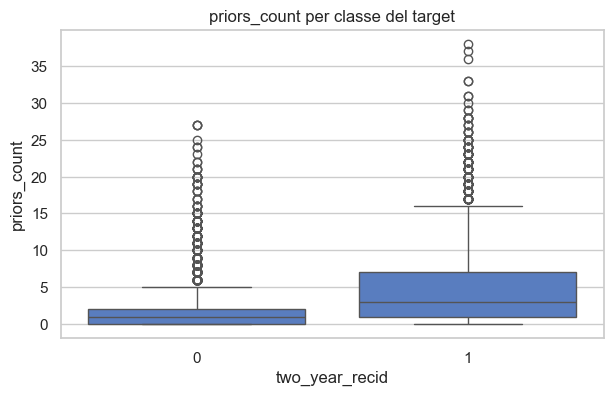

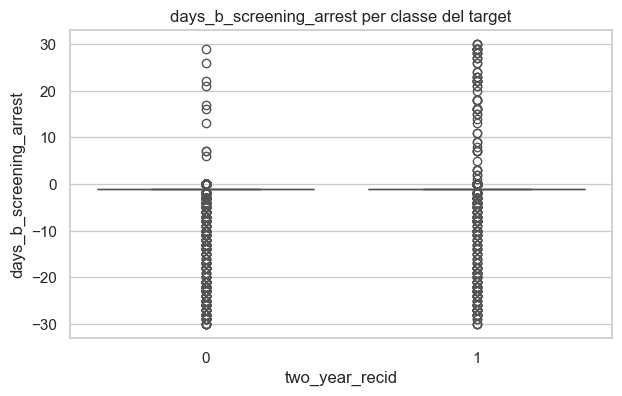

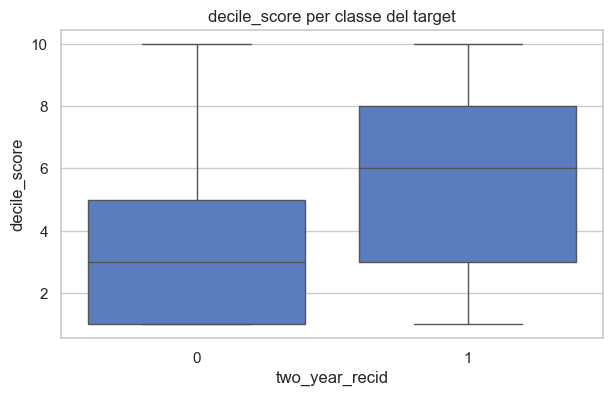

In [109]:
num_target_cols = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]

for col in num_target_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_filtered, x="two_year_recid", y=col)
    plt.title(f"{col} per classe del target")
    plt.show()


___
## 14. analisi variabile target e variabili sensibili race e sex


=== Distribuzione di race ===


,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11



Percentuali di two_year_recid per race:


two_year_recid,0,1
race,,
African-American,47.690,52.310
Asian,74.190,25.810
Caucasian,60.910,39.090
Hispanic,62.870,37.130
Native American,54.550,45.450
Other,63.850,36.150


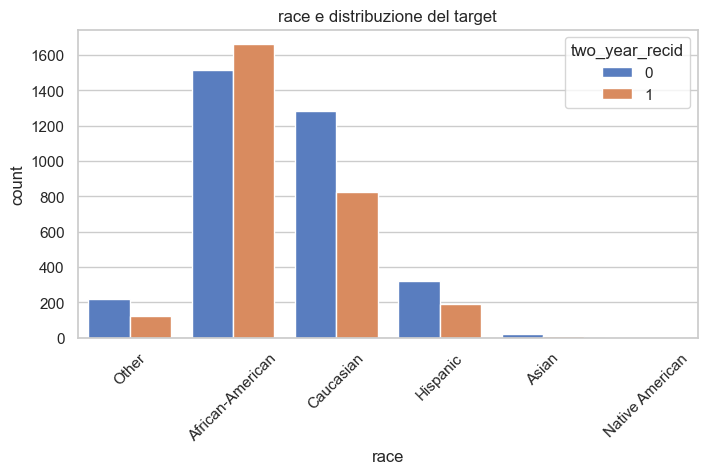


=== Distribuzione di sex ===


,count
sex,
Male,4997
Female,1175



Percentuali di two_year_recid per sex:


two_year_recid,0,1
sex,,
Female,64.850,35.150
Male,52.050,47.950


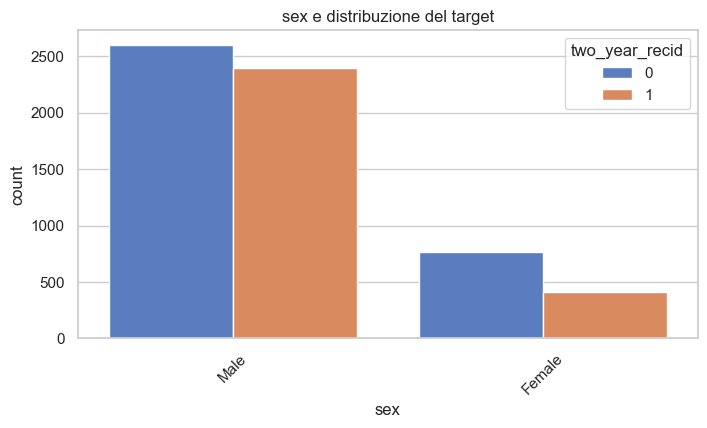

In [110]:
for sensitive_col in ["race", "sex"]:
    print(f"\n=== Distribuzione di {sensitive_col} ===")
    display(df_filtered[sensitive_col].value_counts(dropna=False).to_frame("count"))

    recid_by_group = pd.crosstab(
        df_filtered[sensitive_col],
        df_filtered["two_year_recid"],
        normalize="index"
    ) * 100
    print(f"\nPercentuali di two_year_recid per {sensitive_col}:")
    display(recid_by_group.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_filtered, x=sensitive_col, hue="two_year_recid")
    plt.title(f"{sensitive_col} e distribuzione del target")
    plt.xticks(rotation=45)
    plt.show()

___
## 15. analisi score compas e gruppi sensibili race e sex 


Distribuzione percentuale di score_text per race:


score_text,High,Low,Medium
race,,,
African-American,26.610,42.390,30.990
Asian,9.680,77.420,12.900
Caucasian,10.600,66.900,22.490
Hispanic,9.230,72.300,18.470
Native American,36.360,27.270,36.360
Other,6.410,79.590,13.990


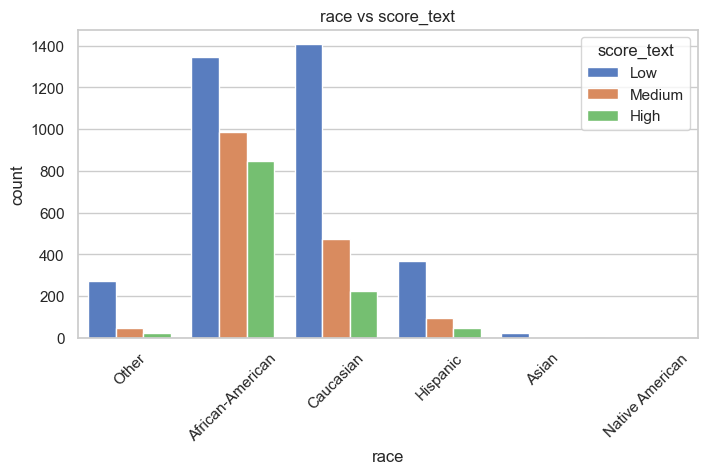


Distribuzione percentuale di score_text per sex:


score_text,High,Low,Medium
sex,,,
Female,12.850,59.490,27.660
Male,19.870,54.470,25.660


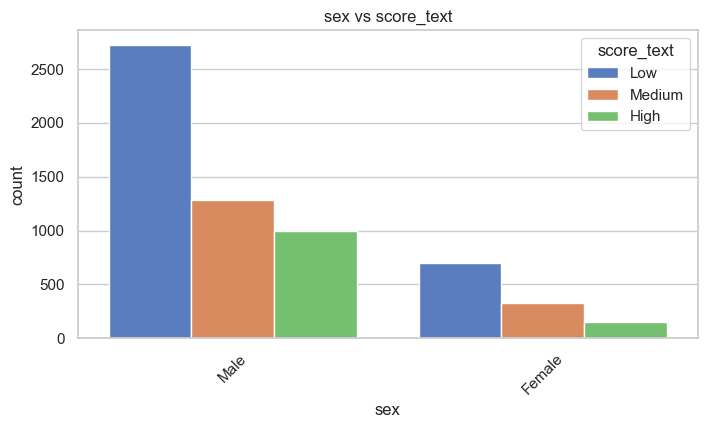

In [111]:
for sensitive_col in ["race", "sex"]:
    score_summary = pd.crosstab(
        df_filtered[sensitive_col],
        df_filtered["score_text"],
        normalize="index"
    ) * 100

    print(f"\nDistribuzione percentuale di score_text per {sensitive_col}:")
    display(score_summary.round(2))

    plt.figure(figsize=(8,4))
    sns.countplot(data=df_filtered, x=sensitive_col, hue="score_text")
    plt.title(f"{sensitive_col} vs score_text")
    plt.xticks(rotation=45)
    plt.show()

___
## 16. eliminazione categorie rare

In [112]:
df_final = df_filtered.copy()

threshold = 0.01  # soglia dell'1%

race_freq = df_final["race"].value_counts(normalize=True)
rare_races = race_freq[race_freq < threshold].index

print("Categorie rare da eliminare:")
print(list(rare_races))

df_final = df_final[~df_final["race"].isin(rare_races)].copy()

print("Shape prima dell'eliminazione:", df_filtered.shape)
print("Shape dopo l'eliminazione:", df_final.shape)

print("\nDistribuzione finale di race:")
print(df_final["race"].value_counts())

print("\nPercentuali finali:")
print(round(df_final["race"].value_counts(normalize=True) * 100, 2))

Categorie rare da eliminare:
['Asian', 'Native American']
Shape prima dell'eliminazione: (6172, 11)
Shape dopo l'eliminazione: (6130, 11)

Distribuzione finale di race:
race
African-American    3175
Caucasian           2103
Hispanic             509
Other                343
Name: count, dtype: int64

Percentuali finali:
race
African-American   51.790
Caucasian          34.310
Hispanic            8.300
Other               5.600
Name: proportion, dtype: float64


___
## 17. riassunto finale

In [113]:
df_nodup = df_raw.drop_duplicates()
df_selected = df_nodup[cols].copy()

shape_summary = pd.DataFrame({
    "fase": [
        "Dataset originale",
        "Dopo rimozione duplicati",
        "Dopo selezione variabili",
        "Dopo filtro ProPublica", 
        "Dopo filtro categorie rare dataset finale"
    ],
    "n_righe": [
        df_raw.shape[0],
        df_nodup.shape[0],
        df_selected.shape[0],
        df_filtered.shape[0],
        df_final.shape[0]
    ],
    "n_colonne": [
        df_raw.shape[1],
        df_nodup.shape[1],
        df_selected.shape[1],
        df_filtered.shape[1],
        df_final.shape[1]
    ]
})

display(shape_summary)

,fase,n_righe,n_colonne
0,Dataset originale,7214,53
1,Dopo rimozione duplicati,7214,53
2,Dopo selezione variabili,7214,11
3,Dopo filtro ProPublica,6172,11
4,Dopo filtro categorie rare dataset finale,6130,11


In [114]:
# Esportazione dataset finale per Orange
output_path = "compas_clean_for_orange.csv"

df_final.to_csv(output_path, index=False)

print(f"Dataset esportato correttamente in: {output_path}")
print(f"Shape finale: {df_final.shape}")
df_final.head()

Dataset esportato correttamente in: compas_clean_for_orange.csv
Shape finale: (6130, 11)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,is_recid,score_text,decile_score,two_year_recid
0,69,Greater than 45,Male,Other,0,-1.000,F,0,Low,1,0
1,34,25 - 45,Male,African-American,0,-1.000,F,1,Low,3,1
2,24,Less than 25,Male,African-American,4,-1.000,F,1,Low,4,1
5,44,25 - 45,Male,Other,0,0.000,M,0,Low,1,0
6,41,25 - 45,Male,Caucasian,14,-1.000,F,1,Medium,6,1


___
# Preprocessing per la modellazione predittiva in Python


In questa fase il dataset viene preparato per l’addestramento dei modelli predittivi.  
Il preprocessing include:
-  la separazione tra variabili indipendenti e variabile target;
- la gestione delle variabili categoriche tramite codifica one-hot
- la suddivisione del dataset in training set e test set 
- la standardizzazione delle variabili numeriche.

La variabile target dell’analisi è `two_year_recid`, che indica se il soggetto ha recidivato entro due anni.

In [115]:
# Creazione di una copia del dataset finale
df_model = df_final.copy()

print("Shape dataset per la modellazione:", df_model.shape)
df_model.head()

Shape dataset per la modellazione: (6130, 11)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,is_recid,score_text,decile_score,two_year_recid
0,69,Greater than 45,Male,Other,0,-1.000,F,0,Low,1,0
1,34,25 - 45,Male,African-American,0,-1.000,F,1,Low,3,1
2,24,Less than 25,Male,African-American,4,-1.000,F,1,Low,4,1
5,44,25 - 45,Male,Other,0,0.000,M,0,Low,1,0
6,41,25 - 45,Male,Caucasian,14,-1.000,F,1,Medium,6,1


___
## 18 Separazione tra variabili indipendenti e variabile target

La variabile target è `two_year_recid`.  
Le altre variabili vengono considerate come predittori, ad eccezione di `is_recid`, che viene esclusa perché rappresenta un’informazione molto vicina alla recidiva osservata e potrebbe introdurre leakage informativo.

In [116]:
# Separazione tra variabili indipendenti X e target y

target = "two_year_recid"

features_to_drop = [
    target,
    "is_recid"
]

X = df_model.drop(columns=features_to_drop)
y = df_model[target]

print("Shape X:", X.shape)
print("Shape y:", y.shape)

display(X.head())
display(y.value_counts(normalize=True).round(3))

Shape X: (6130, 9)
Shape y: (6130,)


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,score_text,decile_score
0,69,Greater than 45,Male,Other,0,-1.000,F,Low,1
1,34,25 - 45,Male,African-American,0,-1.000,F,Low,3
2,24,Less than 25,Male,African-American,4,-1.000,F,Low,4
5,44,25 - 45,Male,Other,0,0.000,M,Low,1
6,41,25 - 45,Male,Caucasian,14,-1.000,F,Medium,6


two_year_recid
0   0.544
1   0.456
Name: proportion, dtype: float64

In [117]:
print("Numero colonne in df_model:", df_model.shape[1])
print("Colonne df_model:")
print(df_model.columns.tolist())

print("\nNumero colonne in X:", X.shape[1])
print("Colonne X:")
print(X.columns.tolist())

Numero colonne in df_model: 11
Colonne df_model:
['age', 'age_cat', 'sex', 'race', 'priors_count', 'days_b_screening_arrest', 'c_charge_degree', 'is_recid', 'score_text', 'decile_score', 'two_year_recid']

Numero colonne in X: 9
Colonne X:
['age', 'age_cat', 'sex', 'race', 'priors_count', 'days_b_screening_arrest', 'c_charge_degree', 'score_text', 'decile_score']


___
## 19 identifico variabili 

In [118]:
# Identificazione delle variabili numeriche e categoriche

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("Variabili numeriche:")
print(numeric_features)

print("\nVariabili categoriche:")
print(categorical_features)

Variabili numeriche:
['age', 'priors_count', 'days_b_screening_arrest', 'decile_score']

Variabili categoriche:
['age_cat', 'sex', 'race', 'c_charge_degree', 'score_text']


___ 
## 20. divisione train e test

In [119]:
!pip install scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [120]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nDistribuzione target nel training set:")
print(y_train.value_counts(normalize=True).round(3))

print("\nDistribuzione target nel test set:")
print(y_test.value_counts(normalize=True).round(3))

# Calcolo della divisione percentuale tra training set e test set

totale_osservazioni = len(X)

perc_train = (len(X_train) / totale_osservazioni) * 100
perc_test = (len(X_test) / totale_osservazioni) * 100

print("\nDivisione percentuale del dataset:")
print(f"Training set: {perc_train:.2f}%")
print(f"Test set: {perc_test:.2f}%")

X_train: (4291, 9)
X_test: (1839, 9)
y_train: (4291,)
y_test: (1839,)

Distribuzione target nel training set:
two_year_recid
0   0.544
1   0.456
Name: proportion, dtype: float64

Distribuzione target nel test set:
two_year_recid
0   0.544
1   0.456
Name: proportion, dtype: float64

Divisione percentuale del dataset:
Training set: 70.00%
Test set: 30.00%


___
## 21. Standardizzazione + One-Hot Encoding

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

StandardScaler → standardizza le variabili numeriche
OneHotEncoder → trasforma le variabili categoriche in variabili dummy
drop="first" → evita perfetta multicollinearità
handle_unknown="ignore" → evita errori se nel test set compare una categoria nuova

In [122]:
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

print("Shape X_train preprocessato:", X_train_preprocessed.shape)
print("Shape X_test preprocessato:", X_test_preprocessed.shape)

Shape X_train preprocessato: (4291, 13)
Shape X_test preprocessato: (1839, 13)


recupero nomi delle nuove variabili create con OneHotEncoder

In [123]:
# Nomi delle feature numeriche
num_feature_names = numeric_features

# Nomi delle feature categoriche trasformate
cat_feature_names = preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features)

# Nomi finali di tutte le feature
feature_names = list(num_feature_names) + list(cat_feature_names)

print("Numero totale di feature dopo preprocessing:", len(feature_names))
print(feature_names)

Numero totale di feature dopo preprocessing: 13
['age', 'priors_count', 'days_b_screening_arrest', 'decile_score', 'age_cat_Greater than 45', 'age_cat_Less than 25', 'sex_Male', 'race_Caucasian', 'race_Hispanic', 'race_Other', 'c_charge_degree_M', 'score_text_Low', 'score_text_Medium']


dataframe per leggere meglio

In [124]:
# Creazione dei DataFrame preprocessati

X_train_preprocessed_df = pd.DataFrame(
    X_train_preprocessed.toarray() if hasattr(X_train_preprocessed, "toarray") else X_train_preprocessed,
    columns=feature_names,
    index=X_train.index
)

X_test_preprocessed_df = pd.DataFrame(
    X_test_preprocessed.toarray() if hasattr(X_test_preprocessed, "toarray") else X_test_preprocessed,
    columns=feature_names,
    index=X_test.index
)

display(X_train_preprocessed_df.head())

,age,priors_count,days_b_screening_arrest,decile_score,age_cat_Greater than 45,age_cat_Less than 25,sex_Male,race_Caucasian,race_Hispanic,race_Other,c_charge_degree_M,score_text_Low,score_text_Medium
4814,-0.385,-0.273,0.145,-1.211,0.000,0.000,1.000,0.000,0.000,1.000,0.000,1.000,0.000
6761,-0.213,0.144,0.145,1.976,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
5674,-0.642,-0.481,0.336,-0.503,0.000,0.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000
1696,2.017,-0.481,0.145,-1.211,1.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000
4278,-0.985,-0.690,0.145,-0.857,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000


Dopo l’applicazione della standardizzazione e del one-hot encoding, i dati trasformati vengono convertiti in DataFrame.  
Questa operazione non modifica il contenuto informativo del dataset, ma consente di mantenere una struttura tabellare leggibile e di associare ogni colonna trasformata al relativo nome della variabile.  

Il passaggio è utile soprattutto per l’interpretazione dei modelli, poiché permette di analizzare in modo più chiaro il ruolo delle variabili numeriche standardizzate e delle variabili dummy generate a partire dalle variabili categoriche.

piccolo check

In [125]:
print("Preprocessing completato correttamente.")

print("\nTraining set preprocessato:")
print(X_train_preprocessed_df.shape)

print("\nTest set preprocessato:")
print(X_test_preprocessed_df.shape)

print("\nTarget training:")
print(y_train.shape)

print("\nTarget test:")
print(y_test.shape)

print("\nValori mancanti nel training set preprocessato:")
print(X_train_preprocessed_df.isna().sum().sum())

print("\nValori mancanti nel test set preprocessato:")
print(X_test_preprocessed_df.isna().sum().sum())

Preprocessing completato correttamente.

Training set preprocessato:
(4291, 13)

Test set preprocessato:
(1839, 13)

Target training:
(4291,)

Target test:
(1839,)

Valori mancanti nel training set preprocessato:
0

Valori mancanti nel test set preprocessato:
0


# Modellazione predittiva

In questa sezione il dataset preprocessato viene utilizzato per addestrare alcuni modelli di classificazione supervisionata.  
L'obiettivo è prevedere la variabile `two_year_recid`, che indica se l'individuo ha avuto una recidiva entro due anni.

La modellazione viene svolta in tre passaggi:

1. addestramento di un modello interpretabile di base, la **Logistic Regression**;
2. addestramento di un modello non lineare più flessibile, la **Random Forest**;
3. confronto delle prestazioni attraverso metriche di classificazione.

Le metriche utilizzate sono:

- **Accuracy**: quota complessiva di previsioni corrette;
- **Precision**: tra i soggetti previsti come recidivi, quanti sono effettivamente recidivi;
- **Recall**: tra i recidivi reali, quanti vengono individuati dal modello;
- **F1-score**: media armonica tra precision e recall;
- **Confusion matrix**: distribuzione di veri positivi, falsi positivi, veri negativi e falsi negativi.

In [126]:
print("Dimensioni dataset pre-processati:")

print("X_train_preprocessed_df:", X_train_preprocessed_df.shape)
print("X_test_preprocessed_df:", X_test_preprocessed_df.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("\nPrime colonne del dataset pre-processato:")
print(X_train_preprocessed_df.columns[:15])

Dimensioni dataset pre-processati:
X_train_preprocessed_df: (4291, 13)
X_test_preprocessed_df: (1839, 13)
y_train: (4291,)
y_test: (1839,)

Prime colonne del dataset pre-processato:
Index(['age', 'priors_count', 'days_b_screening_arrest', 'decile_score',
       'age_cat_Greater than 45', 'age_cat_Less than 25', 'sex_Male',
       'race_Caucasian', 'race_Hispanic', 'race_Other', 'c_charge_degree_M',
       'score_text_Low', 'score_text_Medium'],
      dtype='str')


___
## 22. logistic regression

In [127]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train_preprocessed_df, y_train)

print("Modello Logistic Regression addestrato correttamente.")

Modello Logistic Regression addestrato correttamente.


### Previsioni Logistic Regression

In [128]:
# Previsioni della Logistic Regression sul test set
y_pred_log = log_reg.predict(X_test_preprocessed_df)

# Probabilità previste per la classe positiva, cioè two_year_recid = 1
y_proba_log = log_reg.predict_proba(X_test_preprocessed_df)[:, 1]

print("Prime 10 classi previste:")
print(y_pred_log[:10])

print("\nPrime 10 probabilità previste:")
print(y_proba_log[:10])

Prime 10 classi previste:
[0 0 0 0 0 1 1 1 0 0]

Prime 10 probabilità previste:
[0.42448463 0.35242361 0.38615259 0.38226925 0.14907662 0.70993429
 0.51612077 0.59079662 0.47774158 0.27490445]


Il modello ha prodotto:

Prime 10 classi previste:
[0 0 0 0 0 1 1 1 0 0]

Questo significa che, per i primi 10 soggetti del test set, la Logistic Regression prevede:

0 = non recidiva
1 = recidiva

Poi hai ottenuto anche le probabilità:

[0.424, 0.352, 0.386, 0.382, 0.149, 0.709, 0.516, 0.590, 0.477, 0.274]

Queste indicano quanto il modello considera probabile la recidiva. Per esempio:

0.709 = probabilità stimata del 70,9% di recidiva
0.149 = probabilità stimata del 14,9% di recidiva

La soglia standard è 0.5:

probabilità >= 0.5  → classe prevista 1
probabilità < 0.5   → classe prevista 0

### valutazione

In [129]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("Metriche Logistic Regression:")
print("Accuracy:", round(accuracy_log, 3))
print("Precision:", round(precision_log, 3))
print("Recall:", round(recall_log, 3))
print("F1-score:", round(f1_log, 3))

print("\nClassification report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_log))

Metriche Logistic Regression:
Accuracy: 0.678
Precision: 0.684
Recall: 0.547
F1-score: 0.608

Classification report:
              precision    recall  f1-score   support

           0       0.67      0.79      0.73      1000
           1       0.68      0.55      0.61       839

    accuracy                           0.68      1839
   macro avg       0.68      0.67      0.67      1839
weighted avg       0.68      0.68      0.67      1839


Confusion matrix:
[[788 212]
 [380 459]]


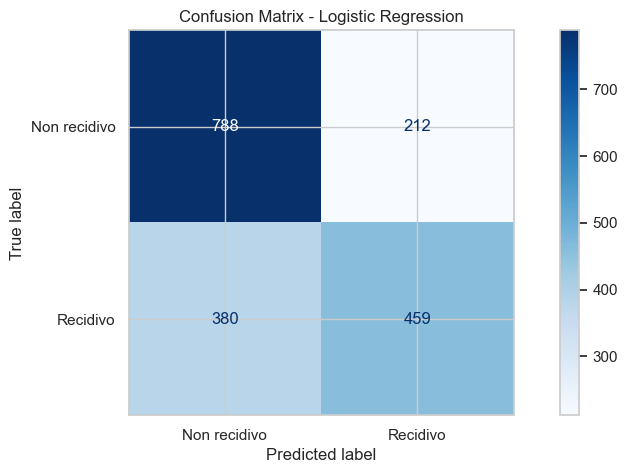

In [130]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    display_labels=["Non recidivo", "Recidivo"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [131]:
results_log = pd.DataFrame({
    "Modello": ["Logistic Regression"],
    "Accuracy": [accuracy_log],
    "Precision": [precision_log],
    "Recall": [recall_log],
    "F1-score": [f1_log]
})

results_log = results_log.round(3)

display(results_log)

,Modello,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.678,0.684,0.547,0.608


___
## 23. Random forest

In [132]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train_preprocessed_df, y_train)

print("Modello Random Forest addestrato correttamente.")

Modello Random Forest addestrato correttamente.


### previsioni

In [133]:
# Previsioni della Random Forest sul test set
y_pred_rf = rf.predict(X_test_preprocessed_df)

# Probabilità previste per la classe positiva, cioè two_year_recid = 1
y_proba_rf = rf.predict_proba(X_test_preprocessed_df)[:, 1]

print("Prime 10 classi previste:")
print(y_pred_rf[:10])

print("\nPrime 10 probabilità previste:")
print(y_proba_rf[:10])

Prime 10 classi previste:
[0 0 0 0 0 0 0 1 0 0]

Prime 10 probabilità previste:
[0.36715298 0.43099356 0.25       0.42924684 0.04       0.45538341
 0.49       0.87383358 0.2298351  0.19853483]


### valutazione

In [134]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Metriche Random Forest:")
print("Accuracy:", round(accuracy_rf, 3))
print("Precision:", round(precision_rf, 3))
print("Recall:", round(recall_rf, 3))
print("F1-score:", round(f1_rf, 3))

print("\nClassification report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Metriche Random Forest:
Accuracy: 0.647
Precision: 0.623
Recall: 0.574
F1-score: 0.598

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.71      0.69      1000
           1       0.62      0.57      0.60       839

    accuracy                           0.65      1839
   macro avg       0.64      0.64      0.64      1839
weighted avg       0.65      0.65      0.65      1839


Confusion matrix:
[[708 292]
 [357 482]]


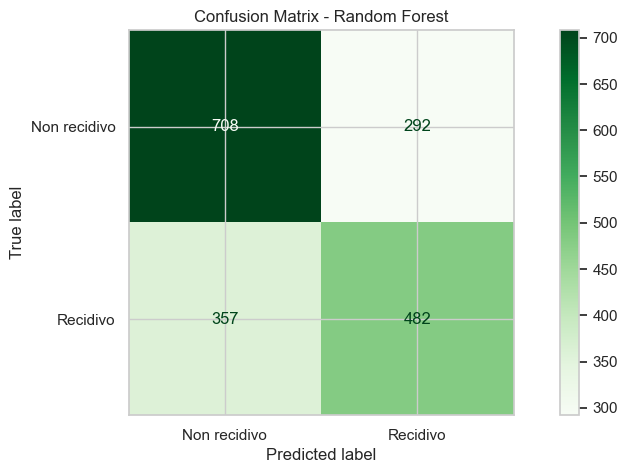

In [135]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Non recidivo", "Recidivo"],
    cmap="Greens"
)

plt.title("Confusion Matrix - Random Forest")
plt.show()

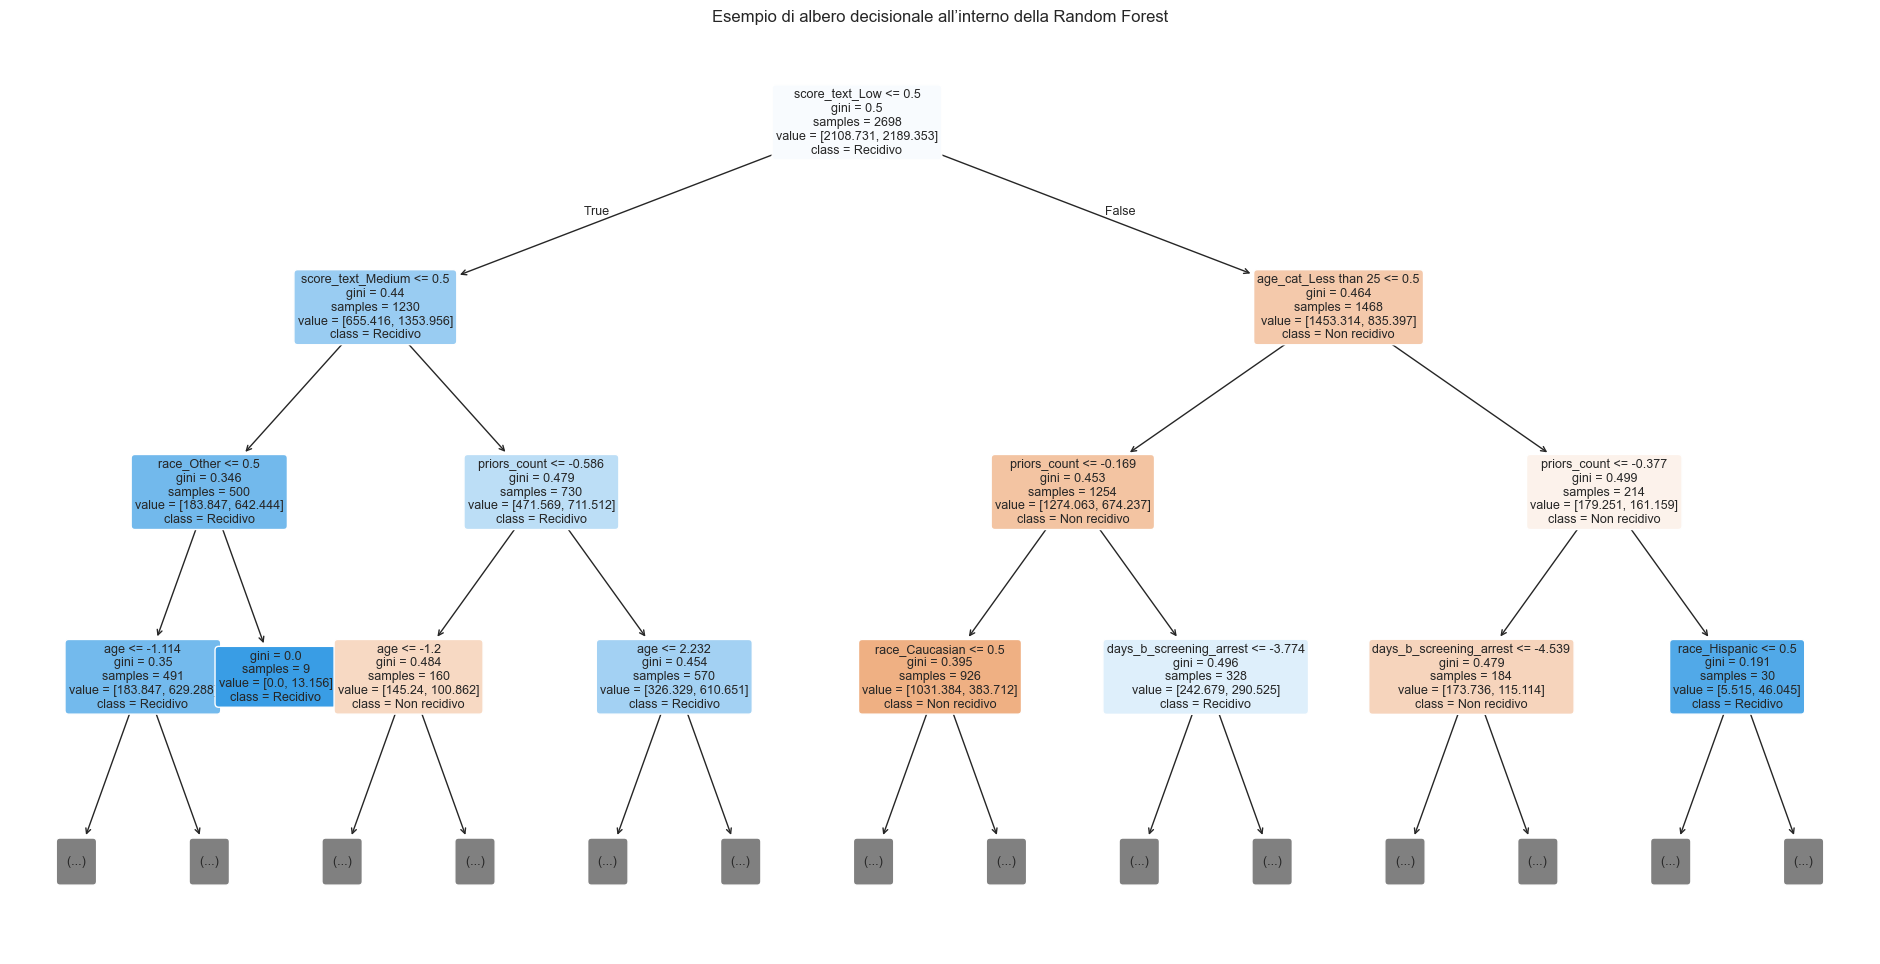

In [136]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    rf.estimators_[0],
    feature_names=X_train_preprocessed_df.columns,
    class_names=["Non recidivo", "Recidivo"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=9
)

plt.title("Esempio di albero decisionale all’interno della Random Forest")
plt.show()

___ 
## 24. confronto tra i modelli

In [137]:
results_rf = pd.DataFrame({
    "Modello": ["Random Forest"],
    "Accuracy": [accuracy_rf],
    "Precision": [precision_rf],
    "Recall": [recall_rf],
    "F1-score": [f1_rf]
})

results_rf = results_rf.round(3)

model_comparison = pd.concat([results_log, results_rf], ignore_index=True)

display(model_comparison)

,Modello,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.678,0.684,0.547,0.608
1,Random Forest,0.647,0.623,0.574,0.598


Dal confronto tra i due modelli emerge che la Logistic Regression ottiene prestazioni complessivamente migliori rispetto alla Random Forest in termini di accuracy, precision e F1-score. La Logistic Regression raggiunge infatti un’accuracy pari a 0.678, mentre la Random Forest ottiene un valore pari a 0.647.

La precision è più elevata nella Logistic Regression, con un valore pari a 0.684 rispetto a 0.623 della Random Forest. Questo indica che, quando la Logistic Regression prevede la classe positiva, cioè la recidiva entro due anni, tende a commettere meno errori rispetto alla Random Forest.

La Random Forest presenta invece una recall leggermente superiore, pari a 0.574 rispetto a 0.547 della Logistic Regression. Ciò significa che la Random Forest riesce a individuare un numero leggermente maggiore di soggetti effettivamente recidivi. Tuttavia, questo miglioramento avviene a fronte di una riduzione della precision e dell’accuracy complessiva.

Nel complesso, la Logistic Regression può essere considerata il modello più stabile tra quelli testati, mentre la Random Forest appare più orientata a classificare un numero maggiore di soggetti come recidivi, aumentando il rischio di falsi positivi.

In [138]:
# Ttabella comparativa con evidenziazione dei migliori risultati per ogni metrica

model_comparison_styled = (
    model_comparison
    .style
    .background_gradient(
        subset=["Accuracy", "Precision", "Recall", "F1-score"],
        cmap="Blues"
    )
    .format({
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-score": "{:.3f}"
    })
)

model_comparison_styled

,Modello,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.678,0.684,0.547,0.608
1,Random Forest,0.647,0.623,0.574,0.598


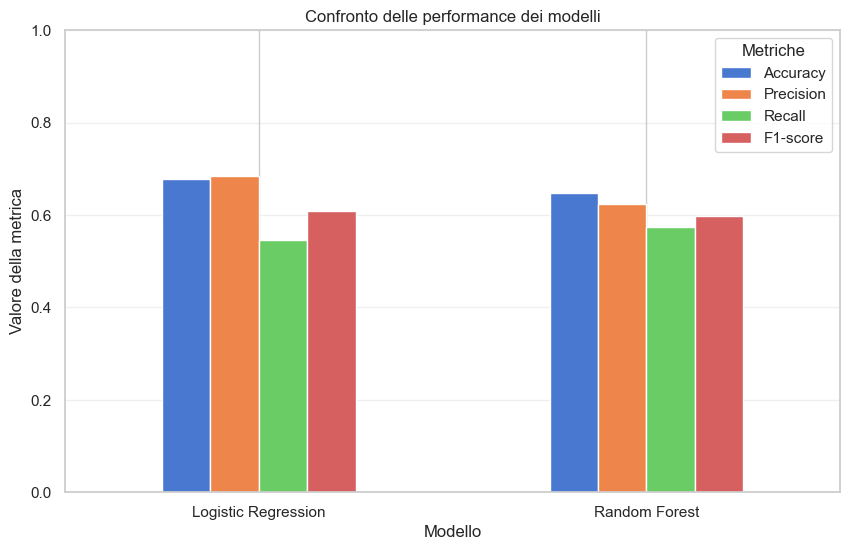

In [139]:
import matplotlib.pyplot as plt

# Impostazione dell'indice per rendere il grafico più leggibile
comparison_plot = model_comparison.set_index("Modello")

comparison_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Confronto delle performance dei modelli")
plt.xlabel("Modello")
plt.ylabel("Valore della metrica")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metriche")
plt.grid(axis="y", alpha=0.3)

plt.show()

___
## 25. curva ROC

In [140]:
from sklearn.metrics import roc_auc_score

roc_auc_log = roc_auc_score(y_test, y_proba_log)
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)

print("ROC-AUC Logistic Regression:", round(roc_auc_log, 3))
print("ROC-AUC Random Forest:", round(roc_auc_rf, 3))

ROC-AUC Logistic Regression: 0.739
ROC-AUC Random Forest: 0.7


In [141]:
model_comparison = pd.DataFrame({
    "Modello": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_log, accuracy_rf],
    "Precision": [precision_log, precision_rf],
    "Recall": [recall_log, recall_rf],
    "F1-score": [f1_log, f1_rf],
    "ROC-AUC": [roc_auc_log, roc_auc_rf]
})

model_comparison = model_comparison.round(3)

display(model_comparison)

,Modello,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.678,0.684,0.547,0.608,0.739
1,Random Forest,0.647,0.623,0.574,0.598,0.700


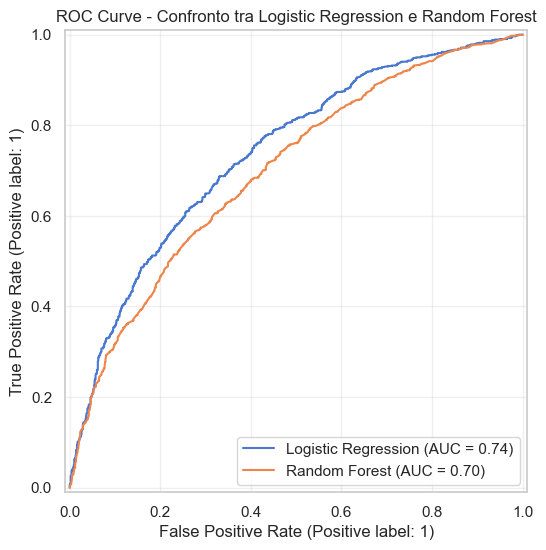

In [142]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_log,
    name="Logistic Regression",
    ax=ax
)

RocCurveDisplay.from_predictions(
    y_test,
    y_proba_rf,
    name="Random Forest",
    ax=ax
)

plt.title("ROC Curve - Confronto tra Logistic Regression e Random Forest")
plt.grid(alpha=0.3)
plt.show()

La curva ROC conferma il confronto già emerso dalle metriche precedenti. La Logistic Regression presenta un valore ROC-AUC pari a 0.739, superiore rispetto alla Random Forest, che ottiene un valore pari a 0.700. 

Ciò indica che la Logistic Regression possiede una maggiore capacità discriminativa, cioè riesce a distinguere in modo più efficace tra soggetti recidivi e non recidivi. Sebbene la Random Forest presenti una recall leggermente più alta, la Logistic Regression mostra prestazioni complessivamente più equilibrate, sia in termini di accuracy sia in termini di ROC-AUC.

Nel complesso, i risultati suggeriscono che, nel caso specifico del dataset analizzato, un modello più complesso come la Random Forest non produce un miglioramento rispetto a un modello più semplice e interpretabile come la Logistic Regression.

___
## 26. analisi fairness

Dopo aver valutato le prestazioni generali dei modelli, l’analisi si concentra sulla distribuzione degli errori tra gruppi differenti.  
A questo scopo viene creato un nuovo DataFrame contenente i valori reali della variabile target, le previsioni dei modelli e alcune variabili sensibili del dataset originale, in particolare `race` e `sex`.

Questo passaggio consente di verificare se i modelli producono tassi di errore differenti tra gruppi razziali o tra uomini e donne.

In [143]:
# Creazione del DataFrame per l'analisi fairness

fairness_df = X_test.copy()

fairness_df["y_true"] = y_test
fairness_df["y_pred_log"] = y_pred_log
fairness_df["y_proba_log"] = y_proba_log
fairness_df["y_pred_rf"] = y_pred_rf
fairness_df["y_proba_rf"] = y_proba_rf

display(fairness_df.head())

,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,score_text,decile_score,y_true,y_pred_log,y_proba_log,y_pred_rf,y_proba_rf
5782,22,Less than 25,Female,Hispanic,1,-1.000,F,Medium,5,0,0,0.424,0,0.367
4244,23,Less than 25,Female,African-American,0,-1.000,M,Low,4,0,0,0.352,0,0.431
1921,38,25 - 45,Male,Caucasian,2,0.000,F,Low,4,1,0,0.386,0,0.250
198,23,Less than 25,Female,African-American,1,-1.000,M,Low,4,0,0,0.382,0,0.429
1036,53,Greater than 45,Female,Caucasian,0,0.000,M,Low,1,0,0,0.149,0,0.040


### fairness per race

funzione su regressione

In [144]:
def fairness_metrics_by_group(df, group_col, pred_col):
    results = []

    for group in df[group_col].unique():
        group_df = df[df[group_col] == group]

        tn = ((group_df["y_true"] == 0) & (group_df[pred_col] == 0)).sum()
        fp = ((group_df["y_true"] == 0) & (group_df[pred_col] == 1)).sum()
        fn = ((group_df["y_true"] == 1) & (group_df[pred_col] == 0)).sum()
        tp = ((group_df["y_true"] == 1) & (group_df[pred_col] == 1)).sum()

        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0

        results.append({
            "Gruppo": group,
            "N": len(group_df),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp,
            "False Positive Rate": fpr,
            "False Negative Rate": fnr,
            "Accuracy": accuracy
        })

    return pd.DataFrame(results).sort_values("N", ascending=False).reset_index(drop=True)

In [145]:
fairness_race_log = fairness_metrics_by_group(
    fairness_df,
    group_col="race",
    pred_col="y_pred_log"
)

fairness_race_log = fairness_race_log.round(3)

display(fairness_race_log)

,Gruppo,N,TN,FP,FN,TP,False Positive Rate,False Negative Rate,Accuracy
0,African-American,941,303,137,170,331,0.311,0.339,0.674
1,Caucasian,653,355,57,137,104,0.138,0.568,0.703
2,Hispanic,136,67,13,41,15,0.162,0.732,0.603
3,Other,109,63,5,32,9,0.074,0.780,0.661


L’analisi dei tassi di errore per la variabile `race` evidenzia differenze significative tra i gruppi. In particolare, per il modello Logistic Regression, il False Positive Rate risulta più elevato per il gruppo African-American, con un valore pari a 0.311, rispetto al gruppo Caucasian, per il quale il valore è pari a 0.138.

Questo significa che, tra i soggetti realmente non recidivi, gli individui appartenenti al gruppo African-American vengono classificati erroneamente come recidivi con maggiore frequenza rispetto agli individui Caucasian.

Al contrario, il False Negative Rate risulta più elevato per il gruppo Caucasian, con un valore pari a 0.568, rispetto al gruppo African-American, che presenta un valore pari a 0.339. Ciò indica che, tra i soggetti realmente recidivi, il modello tende più spesso a classificare erroneamente i soggetti Caucasian come non recidivi.

Questi risultati mostrano che le prestazioni del modello non sono distribuite in modo uniforme tra i gruppi razziali. In particolare, emerge una diversa distribuzione degli errori: per il gruppo African-American è più frequente l’errore di sovrastima del rischio, mentre per il gruppo Caucasian è più frequente l’errore di sottostima del rischio.

funzione su random forest

In [146]:
fairness_race_rf = fairness_metrics_by_group(
    fairness_df,
    group_col="race",
    pred_col="y_pred_rf"
)

fairness_race_rf = fairness_race_rf.round(3)

display(fairness_race_rf)

,Gruppo,N,TN,FP,FN,TP,False Positive Rate,False Negative Rate,Accuracy
0,African-American,941,278,162,179,322,0.368,0.357,0.638
1,Caucasian,653,319,93,121,120,0.226,0.502,0.672
2,Hispanic,136,56,24,34,22,0.300,0.607,0.574
3,Other,109,55,13,23,18,0.191,0.561,0.670


Nel caso della Random Forest, il False Positive Rate risulta più elevato rispetto alla Logistic Regression per tutti i principali gruppi considerati. In particolare, per il gruppo African-American il valore passa da 0.311 a 0.368, mentre per il gruppo Caucasian passa da 0.138 a 0.226.

Anche con la Random Forest permane una differenza tra gruppi razziali: il False Positive Rate del gruppo African-American è pari a 0.368, mentre quello del gruppo Caucasian è pari a 0.226. Ciò indica che anche questo modello tende a classificare più frequentemente come recidivi i soggetti African-American che in realtà non recidivano.

Tuttavia, rispetto alla Logistic Regression, la distanza tra African-American e Caucasian nel False Positive Rate risulta leggermente inferiore. La Random Forest aumenta quindi il numero complessivo di falsi positivi, ma riduce in parte la differenza relativa tra questi due gruppi.

Per quanto riguarda il False Negative Rate, il valore più elevato si osserva per il gruppo Hispanic, seguito dal gruppo Other e dal gruppo Caucasian. Il gruppo African-American presenta invece il False Negative Rate più basso. Anche in questo caso, quindi, gli errori non risultano distribuiti in modo uniforme tra i gruppi.

### fairness a confronto tra i due modelli

In [147]:
fairness_race_log_compare = fairness_race_log.copy()
fairness_race_log_compare["Modello"] = "Logistic Regression"

fairness_race_rf_compare = fairness_race_rf.copy()
fairness_race_rf_compare["Modello"] = "Random Forest"

fairness_race_comparison = pd.concat(
    [fairness_race_log_compare, fairness_race_rf_compare],
    ignore_index=True
)

fairness_race_comparison = fairness_race_comparison[
    ["Modello", "Gruppo", "N", "False Positive Rate", "False Negative Rate", "Accuracy"]
]

display(fairness_race_comparison)

,Modello,Gruppo,N,False Positive Rate,False Negative Rate,Accuracy
0,Logistic Regression,African-American,941,0.311,0.339,0.674
1,Logistic Regression,Caucasian,653,0.138,0.568,0.703
2,Logistic Regression,Hispanic,136,0.162,0.732,0.603
3,Logistic Regression,Other,109,0.074,0.780,0.661
4,Random Forest,African-American,941,0.368,0.357,0.638
5,Random Forest,Caucasian,653,0.226,0.502,0.672
6,Random Forest,Hispanic,136,0.300,0.607,0.574
7,Random Forest,Other,109,0.191,0.561,0.670


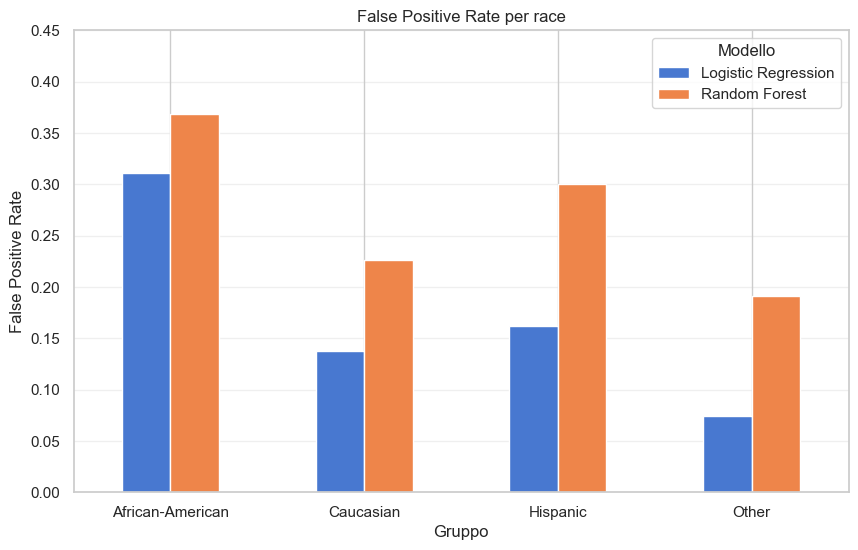

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot della tabella per confrontare i modelli per ciascun gruppo
fpr_race_plot = fairness_race_comparison.pivot(
    index="Gruppo",
    columns="Modello",
    values="False Positive Rate"
)

# Ordine dei gruppi
fpr_race_plot = fpr_race_plot.loc[
    ["African-American", "Caucasian", "Hispanic", "Other"]
]

# Grafico a barre
ax = fpr_race_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("False Positive Rate per race")
plt.xlabel("Gruppo")
plt.ylabel("False Positive Rate")
plt.ylim(0, 0.45)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Modello")

plt.show()

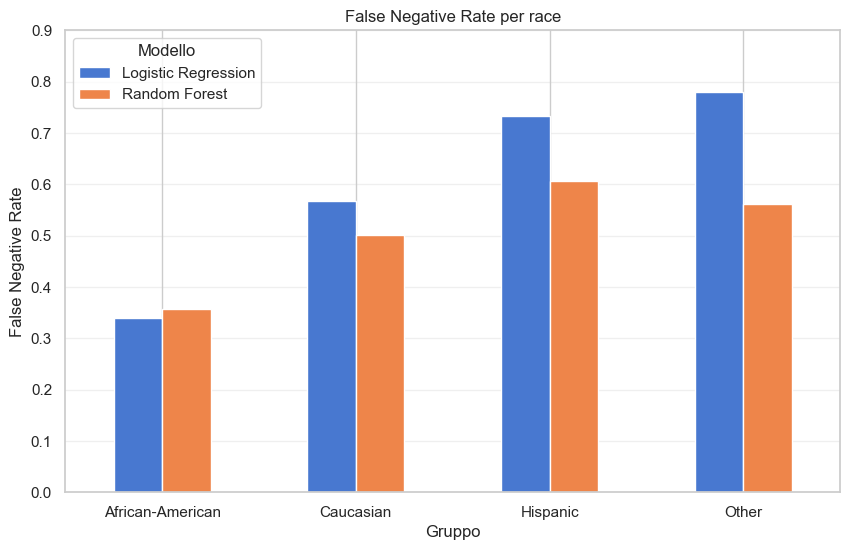

In [149]:
# Pivot della tabella per confrontare i modelli per ciascun gruppo
fnr_race_plot = fairness_race_comparison.pivot(
    index="Gruppo",
    columns="Modello",
    values="False Negative Rate"
)

# Ordine dei gruppi
fnr_race_plot = fnr_race_plot.loc[
    ["African-American", "Caucasian", "Hispanic", "Other"]
]

# Grafico a barre
ax = fnr_race_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("False Negative Rate per race")
plt.xlabel("Gruppo")
plt.ylabel("False Negative Rate")
plt.ylim(0, 0.9)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Modello")

plt.show()

### Fairness per sex

logistic regression

In [150]:
fairness_sex_log = fairness_metrics_by_group(
    fairness_df,
    group_col="sex",
    pred_col="y_pred_log"
)

fairness_sex_log = fairness_sex_log.round(3)

display(fairness_sex_log)

,Gruppo,N,TN,FP,FN,TP,False Positive Rate,False Negative Rate,Accuracy
0,Male,1488,577,195,301,415,0.253,0.420,0.667
1,Female,351,211,17,79,44,0.075,0.642,0.726


random forest

In [151]:
fairness_sex_rf = fairness_metrics_by_group(
    fairness_df,
    group_col="sex",
    pred_col="y_pred_rf"
)

fairness_sex_rf = fairness_sex_rf.round(3)

display(fairness_sex_rf)

,Gruppo,N,TN,FP,FN,TP,False Positive Rate,False Negative Rate,Accuracy
0,Male,1488,523,249,294,422,0.323,0.411,0.635
1,Female,351,185,43,63,60,0.189,0.512,0.698


confronto tra i due modelli

In [152]:
fairness_sex_log_compare = fairness_sex_log.copy()
fairness_sex_log_compare["Modello"] = "Logistic Regression"

fairness_sex_rf_compare = fairness_sex_rf.copy()
fairness_sex_rf_compare["Modello"] = "Random Forest"

fairness_sex_comparison = pd.concat(
    [fairness_sex_log_compare, fairness_sex_rf_compare],
    ignore_index=True
)

fairness_sex_comparison = fairness_sex_comparison[
    ["Modello", "Gruppo", "N", "False Positive Rate", "False Negative Rate", "Accuracy"]
]

display(fairness_sex_comparison)

,Modello,Gruppo,N,False Positive Rate,False Negative Rate,Accuracy
0,Logistic Regression,Male,1488,0.253,0.420,0.667
1,Logistic Regression,Female,351,0.075,0.642,0.726
2,Random Forest,Male,1488,0.323,0.411,0.635
3,Random Forest,Female,351,0.189,0.512,0.698


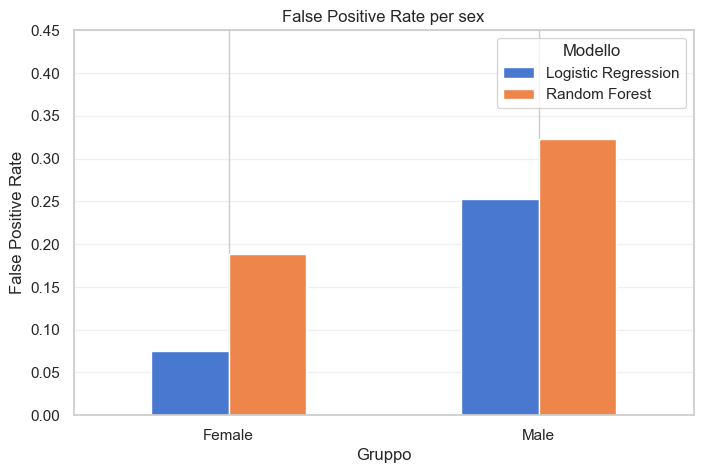

In [153]:
fpr_sex_plot = fairness_sex_comparison.pivot(
    index="Gruppo",
    columns="Modello",
    values="False Positive Rate"
)

ax = fpr_sex_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("False Positive Rate per sex")
plt.xlabel("Gruppo")
plt.ylabel("False Positive Rate")
plt.ylim(0, 0.45)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Modello")

plt.show()

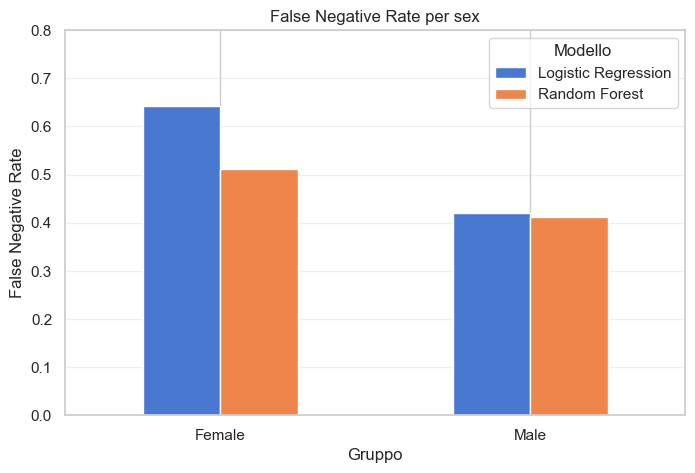

In [154]:
fnr_sex_plot = fairness_sex_comparison.pivot(
    index="Gruppo",
    columns="Modello",
    values="False Negative Rate"
)

ax = fnr_sex_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("False Negative Rate per sex")
plt.xlabel("Gruppo")
plt.ylabel("False Negative Rate")
plt.ylim(0, 0.8)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.legend(title="Modello")

plt.show()

Nel caso della Logistic Regression, il False Positive Rate è più alto per gli uomini:

Male = 0.253
Female = 0.075

Questo significa che, tra i soggetti realmente non recidivi, gli uomini vengono classificati erroneamente come recidivi più spesso delle donne.

Al contrario, il False Negative Rate è più alto per le donne:

Male = 0.420
Female = 0.642

Questo significa che, tra i soggetti realmente recidivi, le donne vengono più spesso classificate erroneamente come non recidive.

___
# analisi controfattuale

In [155]:
# Funzione per trasformare un DataFrame originale usando il preprocessor già addestrato

def transform_counterfactual_df(df_original, preprocessor, feature_names):
    transformed = preprocessor.transform(df_original)
    
    transformed_df = pd.DataFrame(
        transformed.toarray() if hasattr(transformed, "toarray") else transformed,
        columns=feature_names,
        index=df_original.index
    )
    
    return transformed_df

### Analisi controfattuale su race

In [156]:
# Copia del test set originale
cf_race_original = X_test.copy()

# Selezione dei soggetti African-American
mask_african_american = cf_race_original["race"] == "African-American"

# Numero di soggetti coinvolti nello scenario controfattuale
n_african_american = mask_african_american.sum()

print("Numero di soggetti African-American nel test set:", n_african_american)

# Visualizzazione delle prime osservazioni selezionate
display(cf_race_original[mask_african_american].head())

Numero di soggetti African-American nel test set: 941


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,score_text,decile_score
4244,23,Less than 25,Female,African-American,0,-1.000,M,Low,4
198,23,Less than 25,Female,African-American,1,-1.000,M,Low,4
2709,27,25 - 45,Male,African-American,5,0.000,F,Low,3
1338,20,Less than 25,Male,African-American,0,-1.000,F,Medium,7
5643,35,25 - 45,Male,African-American,6,-1.000,F,Low,3


In [157]:
# Creazione della copia controfattuale
cf_race_modified = cf_race_original.copy()

# Modifica della variabile race solo per i soggetti African-American
cf_race_modified.loc[mask_african_american, "race"] = "Caucasian"

# Controllo della modifica effettuata
comparison_race_values = pd.DataFrame({
    "race_originale": cf_race_original.loc[mask_african_american, "race"],
    "race_controfattuale": cf_race_modified.loc[mask_african_american, "race"]
})

display(comparison_race_values.head())

,race_originale,race_controfattuale
4244,African-American,Caucasian
198,African-American,Caucasian
2709,African-American,Caucasian
1338,African-American,Caucasian
5643,African-American,Caucasian


### Controllo delle variabili non modificate

Per verificare che l’analisi controfattuale sia stata costruita correttamente, viene controllato che tutte le variabili diverse da `race` siano rimaste identiche tra il dataset originale e quello controfattuale.

In [158]:
# Verifica che tutte le altre colonne siano rimaste uguali

columns_except_race = [col for col in X_test.columns if col != "race"]

same_other_columns = (
    cf_race_original.loc[mask_african_american, columns_except_race]
    .equals(cf_race_modified.loc[mask_african_american, columns_except_race])
)

print("Le altre variabili sono rimaste invariate?", same_other_columns)

Le altre variabili sono rimaste invariate? True


Il dataset controfattuale viene trasformato utilizzando lo stesso `preprocessor` già addestrato sul training set.  

Applicare lo stesso preprocessing garantisce che il dataset controfattuale abbia le stesse colonne e lo stesso formato del test set utilizzato nella valutazione dei modelli.

In [159]:
# Trasformazione del dataset controfattuale con il preprocessor già addestrato

cf_race_preprocessed_df = transform_counterfactual_df(
    cf_race_modified,
    preprocessor,
    feature_names
)

print("Dimensioni dataset controfattuale preprocessato:", cf_race_preprocessed_df.shape)

display(cf_race_preprocessed_df.head())

Dimensioni dataset controfattuale preprocessato: (1839, 13)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat_Greater than 45,age_cat_Less than 25,sex_Male,race_Caucasian,race_Hispanic,race_Other,c_charge_degree_M,score_text_Low,score_text_Medium
5782,-1.071,-0.481,0.145,0.205,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000
4244,-0.985,-0.690,0.145,-0.149,0.000,1.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000
1921,0.301,-0.273,0.336,-0.149,0.000,0.000,1.000,1.000,0.000,0.000,0.000,1.000,0.000
198,-0.985,-0.481,0.145,-0.149,0.000,1.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000
1036,1.588,-0.690,0.336,-1.211,1.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000


### Predizioni sul dataset controfattuale

In [160]:
# Predizioni controfattuali per lo scenario race African-American -> Caucasian

cf_pred_log_race = log_reg.predict(cf_race_preprocessed_df)
cf_proba_log_race = log_reg.predict_proba(cf_race_preprocessed_df)[:, 1]

cf_pred_rf_race = rf.predict(cf_race_preprocessed_df)
cf_proba_rf_race = rf.predict_proba(cf_race_preprocessed_df)[:, 1]

print("Predizioni controfattuali calcolate correttamente.")

Predizioni controfattuali calcolate correttamente.


In [162]:
# Tabella di confronto originale vs controfattuale per race

counterfactual_race_results = pd.DataFrame({
    "race_originale": cf_race_original["race"],
    "race_controfattuale": cf_race_modified["race"],
    "y_true": y_test,
    
    "pred_log_originale": y_pred_log,
    "pred_log_controfattuale": cf_pred_log_race,
    "proba_log_originale": y_proba_log,
    "proba_log_controfattuale": cf_proba_log_race,
    
    "pred_rf_originale": y_pred_rf,
    "pred_rf_controfattuale": cf_pred_rf_race,
    "proba_rf_originale": y_proba_rf,
    "proba_rf_controfattuale": cf_proba_rf_race
})

# Manteniamo solo i soggetti effettivamente modificati
counterfactual_race_results = counterfactual_race_results[mask_african_american].copy()

# Calcolo della variazione di probabilità
counterfactual_race_results["diff_proba_log"] = (
    counterfactual_race_results["proba_log_controfattuale"]
    - counterfactual_race_results["proba_log_originale"]
)

counterfactual_race_results["diff_proba_rf"] = (
    counterfactual_race_results["proba_rf_controfattuale"]
    - counterfactual_race_results["proba_rf_originale"]
)

# Verifica se la classe prevista cambia
counterfactual_race_results["classe_cambiata_log"] = (
    counterfactual_race_results["pred_log_originale"]
    != counterfactual_race_results["pred_log_controfattuale"]
)

counterfactual_race_results["classe_cambiata_rf"] = (
    counterfactual_race_results["pred_rf_originale"]
    != counterfactual_race_results["pred_rf_controfattuale"]
)

display(counterfactual_race_results.head())

,race_originale,race_controfattuale,y_true,pred_log_originale,pred_log_controfattuale,proba_log_originale,proba_log_controfattuale,pred_rf_originale,pred_rf_controfattuale,proba_rf_originale,proba_rf_controfattuale,diff_proba_log,diff_proba_rf,classe_cambiata_log,classe_cambiata_rf
4244,African-American,Caucasian,0,0,0,0.352,0.375,0,0,0.431,0.102,0.022,-0.329,False,False
198,African-American,Caucasian,0,0,0,0.382,0.405,0,0,0.429,0.193,0.023,-0.237,False,False
2709,African-American,Caucasian,1,1,1,0.516,0.540,0,0,0.490,0.444,0.024,-0.046,False,False
1338,African-American,Caucasian,1,1,1,0.591,0.614,1,1,0.874,0.960,0.023,0.086,False,False
5643,African-American,Caucasian,0,0,1,0.478,0.502,0,0,0.230,0.275,0.024,0.045,True,False


In [163]:
cf_race_view = counterfactual_race_results[
    [
        "race_originale",
        "race_controfattuale",
        "y_true",
        "pred_log_originale",
        "pred_log_controfattuale",
        "proba_log_originale",
        "proba_log_controfattuale",
        "diff_proba_log",
        "classe_cambiata_log",
        "pred_rf_originale",
        "pred_rf_controfattuale",
        "proba_rf_originale",
        "proba_rf_controfattuale",
        "diff_proba_rf",
        "classe_cambiata_rf"
    ]
].copy()

cf_race_view.head(10).style.background_gradient(
    subset=[
        "proba_log_originale",
        "proba_log_controfattuale",
        "diff_proba_log",
        "proba_rf_originale",
        "proba_rf_controfattuale",
        "diff_proba_rf"
    ],
    cmap="coolwarm"
).format({
    "proba_log_originale": "{:.3f}",
    "proba_log_controfattuale": "{:.3f}",
    "diff_proba_log": "{:.3f}",
    "proba_rf_originale": "{:.3f}",
    "proba_rf_controfattuale": "{:.3f}",
    "diff_proba_rf": "{:.3f}"
})

,race_originale,race_controfattuale,y_true,pred_log_originale,pred_log_controfattuale,proba_log_originale,proba_log_controfattuale,diff_proba_log,classe_cambiata_log,pred_rf_originale,pred_rf_controfattuale,proba_rf_originale,proba_rf_controfattuale,diff_proba_rf,classe_cambiata_rf
4244,African-American,Caucasian,0,0,0,0.352,0.375,0.022,False,0,0,0.431,0.102,-0.329,False
198,African-American,Caucasian,0,0,0,0.382,0.405,0.023,False,0,0,0.429,0.193,-0.237,False
2709,African-American,Caucasian,1,1,1,0.516,0.540,0.024,False,0,0,0.490,0.444,-0.046,False
1338,African-American,Caucasian,1,1,1,0.591,0.614,0.023,False,1,1,0.874,0.960,0.086,False
5643,African-American,Caucasian,0,0,1,0.478,0.502,0.024,True,0,0,0.230,0.275,0.045,False
573,African-American,Caucasian,0,0,0,0.275,0.294,0.019,False,0,0,0.199,0.010,-0.189,False
6148,African-American,Caucasian,0,1,1,0.738,0.756,0.018,False,1,1,0.589,0.885,0.295,False
2364,African-American,Caucasian,0,0,0,0.199,0.214,0.016,False,0,0,0.439,0.136,-0.304,False
4906,African-American,Caucasian,1,1,1,0.532,0.555,0.024,False,0,0,0.240,0.420,0.180,False
812,African-American,Caucasian,0,0,0,0.419,0.443,0.023,False,1,0,0.504,0.156,-0.348,True


In [164]:
race_log_changed = counterfactual_race_results["classe_cambiata_log"].mean()
race_rf_changed = counterfactual_race_results["classe_cambiata_rf"].mean()

race_cf_summary = pd.DataFrame({
    "Scenario": ["African-American -> Caucasian", "African-American -> Caucasian"],
    "Modello": ["Logistic Regression", "Random Forest"],
    "N osservazioni modificate": [
        len(counterfactual_race_results),
        len(counterfactual_race_results)
    ],
    "Quota classi cambiate": [
        race_log_changed,
        race_rf_changed
    ],
    "Variazione media probabilità": [
        counterfactual_race_results["diff_proba_log"].mean(),
        counterfactual_race_results["diff_proba_rf"].mean()
    ],
    "Variazione mediana probabilità": [
        counterfactual_race_results["diff_proba_log"].median(),
        counterfactual_race_results["diff_proba_rf"].median()
    ],
    "Variazione minima probabilità": [
        counterfactual_race_results["diff_proba_log"].min(),
        counterfactual_race_results["diff_proba_rf"].min()
    ],
    "Variazione massima probabilità": [
        counterfactual_race_results["diff_proba_log"].max(),
        counterfactual_race_results["diff_proba_rf"].max()
    ]
})

race_cf_summary = race_cf_summary.round(3)

display(race_cf_summary)

,Scenario,Modello,N osservazioni modificate,Quota classi cambiate,Variazione media probabilità,Variazione mediana probabilità,Variazione minima probabilità,Variazione massima probabilità
0,African-American -> Caucasian,Logistic Regression,941,0.045,0.020,0.021,0.002,0.024
1,African-American -> Caucasian,Random Forest,941,0.252,0.008,0.000,-0.808,0.750


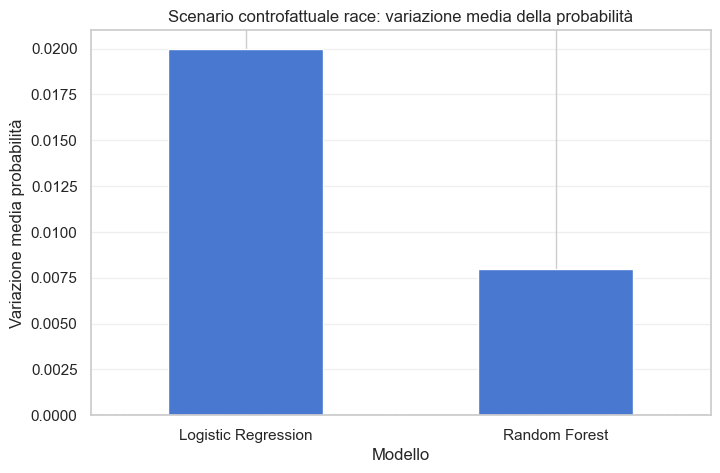

In [165]:
import matplotlib.pyplot as plt

race_mean_plot = race_cf_summary.set_index("Modello")["Variazione media probabilità"]

ax = race_mean_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Scenario controfattuale race: variazione media della probabilità")
plt.xlabel("Modello")
plt.ylabel("Variazione media probabilità")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

logistic regression

In [166]:
race_log_change_table = pd.crosstab(
    counterfactual_race_results["pred_log_originale"],
    counterfactual_race_results["pred_log_controfattuale"],
    rownames=["Predizione originale"],
    colnames=["Predizione controfattuale"]
)

display(race_log_change_table)

Predizione controfattuale,0,1
Predizione originale,,
0,431,42
1,0,468


random forest

In [167]:
race_rf_change_table = pd.crosstab(
    counterfactual_race_results["pred_rf_originale"],
    counterfactual_race_results["pred_rf_controfattuale"],
    rownames=["Predizione originale"],
    colnames=["Predizione controfattuale"]
)

display(race_rf_change_table)

Predizione controfattuale,0,1
Predizione originale,,
0,332,125
1,112,372


### Valutazione delle predizioni controfattuali per race

In [168]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Valori reali per i soli soggetti African-American modificati
y_true_race_cf = counterfactual_race_results["y_true"]

# Metriche originali e controfattuali sullo stesso sottoinsieme di osservazioni
cf_race_eval = pd.DataFrame({
    "Modello": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest"
    ],
    "Scenario": [
        "Originale",
        "Controfattuale",
        "Originale",
        "Controfattuale"
    ],
    "Accuracy": [
        accuracy_score(y_true_race_cf, counterfactual_race_results["pred_log_originale"]),
        accuracy_score(y_true_race_cf, counterfactual_race_results["pred_log_controfattuale"]),
        accuracy_score(y_true_race_cf, counterfactual_race_results["pred_rf_originale"]),
        accuracy_score(y_true_race_cf, counterfactual_race_results["pred_rf_controfattuale"])
    ],
    "Precision": [
        precision_score(y_true_race_cf, counterfactual_race_results["pred_log_originale"]),
        precision_score(y_true_race_cf, counterfactual_race_results["pred_log_controfattuale"]),
        precision_score(y_true_race_cf, counterfactual_race_results["pred_rf_originale"]),
        precision_score(y_true_race_cf, counterfactual_race_results["pred_rf_controfattuale"])
    ],
    "Recall": [
        recall_score(y_true_race_cf, counterfactual_race_results["pred_log_originale"]),
        recall_score(y_true_race_cf, counterfactual_race_results["pred_log_controfattuale"]),
        recall_score(y_true_race_cf, counterfactual_race_results["pred_rf_originale"]),
        recall_score(y_true_race_cf, counterfactual_race_results["pred_rf_controfattuale"])
    ],
    "F1-score": [
        f1_score(y_true_race_cf, counterfactual_race_results["pred_log_originale"]),
        f1_score(y_true_race_cf, counterfactual_race_results["pred_log_controfattuale"]),
        f1_score(y_true_race_cf, counterfactual_race_results["pred_rf_originale"]),
        f1_score(y_true_race_cf, counterfactual_race_results["pred_rf_controfattuale"])
    ]
})

cf_race_eval = cf_race_eval.round(3)

display(cf_race_eval)

,Modello,Scenario,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Originale,0.674,0.707,0.661,0.683
1,Logistic Regression,Controfattuale,0.678,0.694,0.707,0.700
2,Random Forest,Originale,0.638,0.665,0.643,0.654
3,Random Forest,Controfattuale,0.643,0.666,0.661,0.663


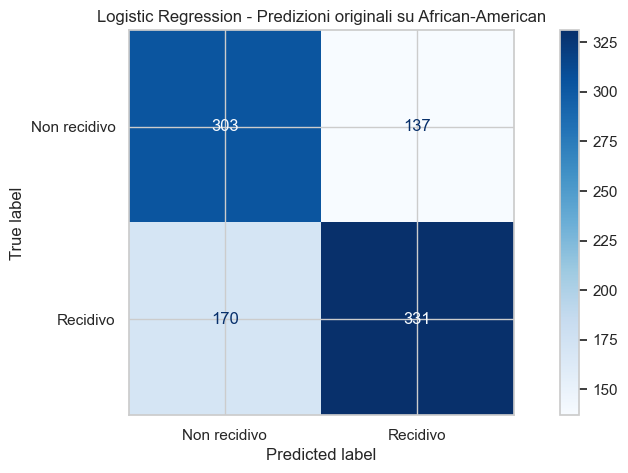

In [169]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_true_race_cf,
    counterfactual_race_results["pred_log_originale"],
    display_labels=["Non recidivo", "Recidivo"],
    cmap="Blues"
)

plt.title("Logistic Regression - Predizioni originali su African-American")
plt.show()

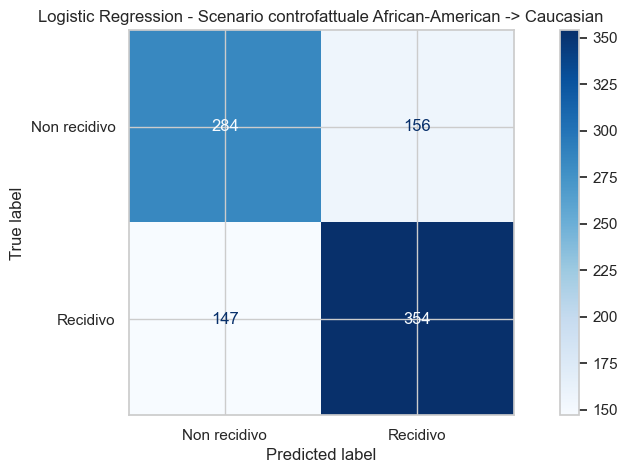

In [170]:
ConfusionMatrixDisplay.from_predictions(
    y_true_race_cf,
    counterfactual_race_results["pred_log_controfattuale"],
    display_labels=["Non recidivo", "Recidivo"],
    cmap="Blues"
)

plt.title("Logistic Regression - Scenario controfattuale African-American -> Caucasian")
plt.show()

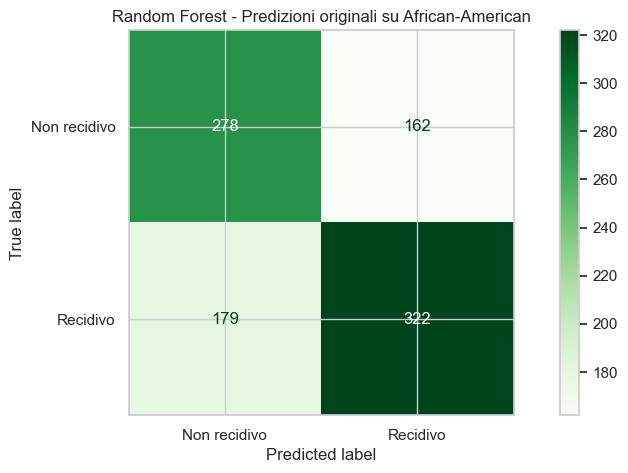

In [171]:
ConfusionMatrixDisplay.from_predictions(
    y_true_race_cf,
    counterfactual_race_results["pred_rf_originale"],
    display_labels=["Non recidivo", "Recidivo"],
    cmap="Greens"
)

plt.title("Random Forest - Predizioni originali su African-American")
plt.show()

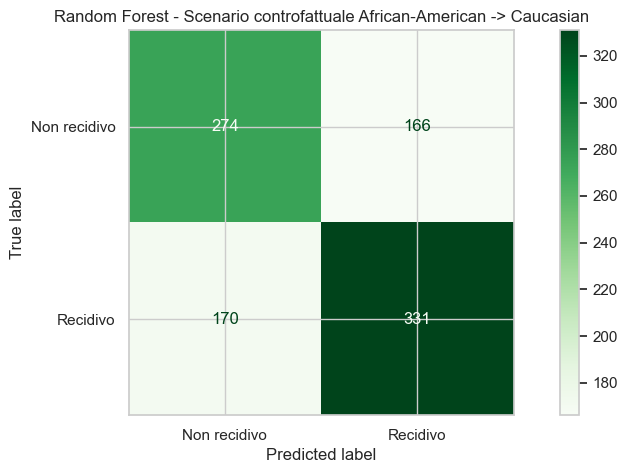

In [172]:
ConfusionMatrixDisplay.from_predictions(
    y_true_race_cf,
    counterfactual_race_results["pred_rf_controfattuale"],
    display_labels=["Non recidivo", "Recidivo"],
    cmap="Greens"
)

plt.title("Random Forest - Scenario controfattuale African-American -> Caucasian")
plt.show()

L’analisi controfattuale relativa alla variabile `race` è stata condotta modificando artificialmente il valore della variabile da `African-American` a `Caucasian` per i soggetti del test set appartenenti originariamente al gruppo African-American. Tutte le altre variabili sono state mantenute invariate, al fine di osservare se e in che misura il cambiamento della sola variabile razziale potesse incidere sulle previsioni dei modelli.

Il primo elemento rilevante riguarda il numero di osservazioni coinvolte: l’analisi è stata applicata a 941 soggetti del test set. Dopo la modifica controfattuale, i dati sono stati sottoposti allo stesso preprocessing utilizzato nella fase di addestramento, così da garantire coerenza tra il formato dei dati originali e quello dei dati controfattuali.

I risultati mostrano che la modifica della variabile `race` produce effetti diversi nei due modelli. Nel caso della Logistic Regression, la quota di classi previste che cambia è pari a 0.045, cioè circa il 4,5% delle osservazioni modificate. Questo indica che il modello lineare risulta relativamente stabile rispetto alla modifica controfattuale: nella maggior parte dei casi, il cambiamento da African-American a Caucasian non modifica la classe finale assegnata dal modello. Tuttavia, la variazione media della probabilità stimata è pari a 0.020, indicando un lieve aumento medio della probabilità prevista di recidiva nello scenario controfattuale.

La Random Forest mostra invece una maggiore sensibilità alla modifica della variabile `race`. In questo caso, la quota di classi cambiate è pari a 0.252, cioè circa il 25,2% delle osservazioni modificate. Questo valore è nettamente superiore rispetto a quello osservato per la Logistic Regression e suggerisce che il modello basato su alberi decisionali sia più instabile rispetto allo scenario controfattuale considerato. La variazione media della probabilità stimata è pari a 0.008, quindi contenuta in media, ma la presenza di una quota elevata di cambiamenti di classe indica che per molti casi la modifica della variabile razziale incide comunque sulla decisione finale del modello.

L’analisi delle tabelle di cambiamento della classe prevista consente di approfondire ulteriormente questo risultato. Per la Logistic Regression, i cambiamenti avvengono esclusivamente nella direzione da 0 a 1: alcune osservazioni che originariamente erano classificate come non recidive vengono classificate come recidive nello scenario controfattuale. Non si osservano invece passaggi dalla classe 1 alla classe 0. Questo comportamento indica che, per il modello lineare, la modifica da African-American a Caucasian tende ad aumentare il rischio previsto in alcuni casi, fino a superare la soglia di classificazione.

Per la Random Forest, invece, i cambiamenti avvengono in entrambe le direzioni: alcune osservazioni passano da 0 a 1, mentre altre passano da 1 a 0. Questo suggerisce una maggiore complessità e variabilità del comportamento del modello. La Random Forest, infatti, non reagisce in modo uniforme alla modifica della variabile `race`, ma produce effetti differenti a seconda della combinazione delle altre caratteristiche dell’osservazione.

Anche la valutazione delle metriche nello scenario originale e in quello controfattuale conferma che la modifica di `race` incide sulle prestazioni dei modelli nel sottoinsieme analizzato. Nel caso della Logistic Regression, l’accuracy passa da 0.674 a 0.678, mentre l’F1-score aumenta da 0.683 a 0.700. La recall aumenta da 0.661 a 0.707, indicando che nello scenario controfattuale il modello identifica un numero maggiore di soggetti effettivamente recidivi. La precision diminuisce invece lievemente, passando da 0.707 a 0.694. Anche per la Random Forest si osserva un lieve miglioramento delle metriche: l’accuracy passa da 0.638 a 0.643, la recall da 0.643 a 0.661 e l’F1-score da 0.654 a 0.663.

Nel complesso, l’analisi controfattuale mostra che la variabile `race` ha un effetto sulle previsioni dei modelli, sebbene con intensità diversa. La Logistic Regression appare più stabile e meno sensibile alla modifica della variabile razziale, mentre la Random Forest presenta una maggiore variazione nelle classi previste. Questo risultato è coerente con la maggiore complessità della Random Forest, che può catturare interazioni non lineari tra variabili e reagire in modo più marcato a modifiche anche localizzate del dataset.

È importante sottolineare che questa analisi non deve essere interpretata come una dimostrazione causale. La modifica artificiale della variabile `race`, mantenendo costanti tutte le altre caratteristiche, rappresenta una semplificazione metodologica. Nella realtà, variabili come appartenenza razziale, condizioni socioeconomiche, precedenti penali e caratteristiche del procedimento giudiziario possono essere tra loro correlate. Tuttavia, l’analisi controfattuale svolta consente di osservare la sensibilità dei modelli rispetto a una variabile socialmente rilevante e offre un ulteriore elemento per valutare il rischio di bias algoritmico.

Questi risultati si collegano all’analisi fairness precedente: mentre l’analisi dei tassi di errore per gruppo ha mostrato differenze nella distribuzione di falsi positivi e falsi negativi tra gruppi razziali, l’analisi controfattuale consente di osservare cosa accade modificando direttamente la variabile `race` a livello delle singole osservazioni. In questo senso, le due analisi sono complementari: la prima evidenzia disuguaglianze aggregate tra gruppi, la seconda mostra la sensibilità delle previsioni a cambiamenti puntuali della variabile sensibile.

### analisi controfattuali per sex
Analisi controfattuale su sex: Male → Female


In [173]:
# Copia del test set originale
cf_sex_original = X_test.copy()

# Selezione dei soggetti Male
mask_male = cf_sex_original["sex"] == "Male"

# Numero di soggetti coinvolti nello scenario controfattuale
n_male = mask_male.sum()

print("Numero di soggetti Male nel test set:", n_male)

# Visualizzazione delle prime osservazioni selezionate
display(cf_sex_original[mask_male].head())

Numero di soggetti Male nel test set: 1488


,age,age_cat,sex,race,priors_count,days_b_screening_arrest,c_charge_degree,score_text,decile_score
1921,38,25 - 45,Male,Caucasian,2,0.000,F,Low,4
4912,24,Less than 25,Male,Caucasian,0,-1.000,F,High,10
2709,27,25 - 45,Male,African-American,5,0.000,F,Low,3
1338,20,Less than 25,Male,African-American,0,-1.000,F,Medium,7
5643,35,25 - 45,Male,African-American,6,-1.000,F,Low,3


In [174]:
# Creazione della copia controfattuale
cf_sex_modified = cf_sex_original.copy()

# Modifica della variabile sex solo per i soggetti Male
cf_sex_modified.loc[mask_male, "sex"] = "Female"

# Controllo della modifica effettuata
comparison_sex_values = pd.DataFrame({
    "sex_originale": cf_sex_original.loc[mask_male, "sex"],
    "sex_controfattuale": cf_sex_modified.loc[mask_male, "sex"]
})

display(comparison_sex_values.head())

,sex_originale,sex_controfattuale
1921,Male,Female
4912,Male,Female
2709,Male,Female
1338,Male,Female
5643,Male,Female


In [175]:
# Verifica che tutte le altre colonne siano rimaste uguali

columns_except_sex = [col for col in X_test.columns if col != "sex"]

same_other_columns_sex = (
    cf_sex_original.loc[mask_male, columns_except_sex]
    .equals(cf_sex_modified.loc[mask_male, columns_except_sex])
)

print("Le altre variabili sono rimaste invariate?", same_other_columns_sex)

Le altre variabili sono rimaste invariate? True


In [176]:
# Trasformazione del dataset controfattuale con il preprocessor già addestrato

cf_sex_preprocessed_df = transform_counterfactual_df(
    cf_sex_modified,
    preprocessor,
    feature_names
)

print("Dimensioni dataset controfattuale preprocessato:", cf_sex_preprocessed_df.shape)

display(cf_sex_preprocessed_df.head())

Dimensioni dataset controfattuale preprocessato: (1839, 13)


,age,priors_count,days_b_screening_arrest,decile_score,age_cat_Greater than 45,age_cat_Less than 25,sex_Male,race_Caucasian,race_Hispanic,race_Other,c_charge_degree_M,score_text_Low,score_text_Medium
5782,-1.071,-0.481,0.145,0.205,0.000,1.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000
4244,-0.985,-0.690,0.145,-0.149,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
1921,0.301,-0.273,0.336,-0.149,0.000,0.000,0.000,1.000,0.000,0.000,0.000,1.000,0.000
198,-0.985,-0.481,0.145,-0.149,0.000,1.000,0.000,0.000,0.000,0.000,1.000,1.000,0.000
1036,1.588,-0.690,0.336,-1.211,1.000,0.000,0.000,1.000,0.000,0.000,1.000,1.000,0.000


In [177]:
# Predizioni controfattuali per lo scenario sex Male -> Female

cf_pred_log_sex = log_reg.predict(cf_sex_preprocessed_df)
cf_proba_log_sex = log_reg.predict_proba(cf_sex_preprocessed_df)[:, 1]

cf_pred_rf_sex = rf.predict(cf_sex_preprocessed_df)
cf_proba_rf_sex = rf.predict_proba(cf_sex_preprocessed_df)[:, 1]

print("Predizioni controfattuali calcolate correttamente.")

Predizioni controfattuali calcolate correttamente.


In [178]:
# Tabella di confronto originale vs controfattuale per sex

counterfactual_sex_results = pd.DataFrame({
    "sex_originale": cf_sex_original["sex"],
    "sex_controfattuale": cf_sex_modified["sex"],
    "y_true": y_test,
    
    "pred_log_originale": y_pred_log,
    "pred_log_controfattuale": cf_pred_log_sex,
    "proba_log_originale": y_proba_log,
    "proba_log_controfattuale": cf_proba_log_sex,
    
    "pred_rf_originale": y_pred_rf,
    "pred_rf_controfattuale": cf_pred_rf_sex,
    "proba_rf_originale": y_proba_rf,
    "proba_rf_controfattuale": cf_proba_rf_sex
})

# Manteniamo solo i soggetti effettivamente modificati
counterfactual_sex_results = counterfactual_sex_results[mask_male].copy()

# Calcolo della variazione di probabilità
counterfactual_sex_results["diff_proba_log"] = (
    counterfactual_sex_results["proba_log_controfattuale"]
    - counterfactual_sex_results["proba_log_originale"]
)

counterfactual_sex_results["diff_proba_rf"] = (
    counterfactual_sex_results["proba_rf_controfattuale"]
    - counterfactual_sex_results["proba_rf_originale"]
)

# Verifica se la classe prevista cambia
counterfactual_sex_results["classe_cambiata_log"] = (
    counterfactual_sex_results["pred_log_originale"]
    != counterfactual_sex_results["pred_log_controfattuale"]
)

counterfactual_sex_results["classe_cambiata_rf"] = (
    counterfactual_sex_results["pred_rf_originale"]
    != counterfactual_sex_results["pred_rf_controfattuale"]
)

display(counterfactual_sex_results.head())

,sex_originale,sex_controfattuale,y_true,pred_log_originale,pred_log_controfattuale,proba_log_originale,proba_log_controfattuale,pred_rf_originale,pred_rf_controfattuale,proba_rf_originale,proba_rf_controfattuale,diff_proba_log,diff_proba_rf,classe_cambiata_log,classe_cambiata_rf
1921,Male,Female,1,0,0,0.386,0.304,0,0,0.250,0.190,-0.083,-0.060,False,False
4912,Male,Female,0,1,1,0.710,0.629,0,0,0.455,0.254,-0.081,-0.202,False,False
2709,Male,Female,1,1,0,0.516,0.425,0,0,0.490,0.230,-0.091,-0.260,True,False
1338,Male,Female,1,1,1,0.591,0.500,1,1,0.874,0.740,-0.091,-0.134,False,False
5643,Male,Female,0,0,0,0.478,0.388,0,0,0.230,0.100,-0.090,-0.130,False,False


In [179]:
cf_sex_view = counterfactual_sex_results[
    [
        "sex_originale",
        "sex_controfattuale",
        "y_true",
        "pred_log_originale",
        "pred_log_controfattuale",
        "proba_log_originale",
        "proba_log_controfattuale",
        "diff_proba_log",
        "classe_cambiata_log",
        "pred_rf_originale",
        "pred_rf_controfattuale",
        "proba_rf_originale",
        "proba_rf_controfattuale",
        "diff_proba_rf",
        "classe_cambiata_rf"
    ]
].copy()

cf_sex_view.head(10).style.background_gradient(
    subset=[
        "proba_log_originale",
        "proba_log_controfattuale",
        "diff_proba_log",
        "proba_rf_originale",
        "proba_rf_controfattuale",
        "diff_proba_rf"
    ],
    cmap="coolwarm"
).format({
    "proba_log_originale": "{:.3f}",
    "proba_log_controfattuale": "{:.3f}",
    "diff_proba_log": "{:.3f}",
    "proba_rf_originale": "{:.3f}",
    "proba_rf_controfattuale": "{:.3f}",
    "diff_proba_rf": "{:.3f}"
})

,sex_originale,sex_controfattuale,y_true,pred_log_originale,pred_log_controfattuale,proba_log_originale,proba_log_controfattuale,diff_proba_log,classe_cambiata_log,pred_rf_originale,pred_rf_controfattuale,proba_rf_originale,proba_rf_controfattuale,diff_proba_rf,classe_cambiata_rf
1921,Male,Female,1,0,0,0.386,0.304,-0.083,False,0,0,0.250,0.190,-0.060,False
4912,Male,Female,0,1,1,0.710,0.629,-0.081,False,0,0,0.455,0.254,-0.202,False
2709,Male,Female,1,1,0,0.516,0.425,-0.091,True,0,0,0.490,0.230,-0.260,False
1338,Male,Female,1,1,1,0.591,0.500,-0.091,False,1,1,0.874,0.740,-0.134,False
5643,Male,Female,0,0,0,0.478,0.388,-0.090,False,0,0,0.230,0.100,-0.130,False
7064,Male,Female,0,0,0,0.229,0.171,-0.058,False,0,0,0.235,0.255,0.020,False
6445,Male,Female,1,0,0,0.277,0.210,-0.067,False,1,1,0.530,0.620,0.090,False
6148,Male,Female,0,1,1,0.738,0.661,-0.077,False,1,0,0.589,0.131,-0.459,True
2364,Male,Female,0,0,0,0.199,0.147,-0.052,False,0,0,0.439,0.233,-0.206,False
4906,Male,Female,1,1,0,0.532,0.440,-0.091,True,0,0,0.240,0.340,0.100,False


## cambiamenti di classe attuati

In [188]:
# Tabella dei cambiamenti di classe per Logistic Regression - sex

sex_log_change_table = pd.crosstab(
    counterfactual_sex_results["pred_log_originale"],
    counterfactual_sex_results["pred_log_controfattuale"],
    rownames=["Predizione originale"],
    colnames=["Predizione controfattuale"]
)

display(sex_log_change_table)

Predizione controfattuale,0,1
Predizione originale,,
0,878,0
1,164,446


In [189]:
# Tabella dei cambiamenti di classe per Random Forest - sex

sex_rf_change_table = pd.crosstab(
    counterfactual_sex_results["pred_rf_originale"],
    counterfactual_sex_results["pred_rf_controfattuale"],
    rownames=["Predizione originale"],
    colnames=["Predizione controfattuale"]
)

display(sex_rf_change_table)

Predizione controfattuale,0,1
Predizione originale,,
0,690,127
1,259,412


In [180]:
# Sintesi dello scenario controfattuale sex

sex_log_changed = counterfactual_sex_results["classe_cambiata_log"].mean()
sex_rf_changed = counterfactual_sex_results["classe_cambiata_rf"].mean()

sex_cf_summary = pd.DataFrame({
    "Scenario": ["Male -> Female", "Male -> Female"],
    "Modello": ["Logistic Regression", "Random Forest"],
    "N osservazioni modificate": [
        len(counterfactual_sex_results),
        len(counterfactual_sex_results)
    ],
    "Quota classi cambiate": [
        sex_log_changed,
        sex_rf_changed
    ],
    "Variazione media probabilità": [
        counterfactual_sex_results["diff_proba_log"].mean(),
        counterfactual_sex_results["diff_proba_rf"].mean()
    ],
    "Variazione mediana probabilità": [
        counterfactual_sex_results["diff_proba_log"].median(),
        counterfactual_sex_results["diff_proba_rf"].median()
    ],
    "Variazione minima probabilità": [
        counterfactual_sex_results["diff_proba_log"].min(),
        counterfactual_sex_results["diff_proba_rf"].min()
    ],
    "Variazione massima probabilità": [
        counterfactual_sex_results["diff_proba_log"].max(),
        counterfactual_sex_results["diff_proba_rf"].max()
    ]
})

sex_cf_summary = sex_cf_summary.round(3)

display(sex_cf_summary)

,Scenario,Modello,N osservazioni modificate,Quota classi cambiate,Variazione media probabilità,Variazione mediana probabilità,Variazione minima probabilità,Variazione massima probabilità
0,Male -> Female,Logistic Regression,1488,0.110,-0.074,-0.079,-0.092,-0.007
1,Male -> Female,Random Forest,1488,0.259,-0.060,-0.056,-0.705,0.796


### valutazione predizioni

In [181]:
# Valori reali per i soli soggetti Male modificati
y_true_sex_cf = counterfactual_sex_results["y_true"]

# Metriche originali e controfattuali sullo stesso sottoinsieme di osservazioni
cf_sex_eval = pd.DataFrame({
    "Modello": [
        "Logistic Regression",
        "Logistic Regression",
        "Random Forest",
        "Random Forest"
    ],
    "Scenario": [
        "Originale",
        "Controfattuale",
        "Originale",
        "Controfattuale"
    ],
    "Accuracy": [
        accuracy_score(y_true_sex_cf, counterfactual_sex_results["pred_log_originale"]),
        accuracy_score(y_true_sex_cf, counterfactual_sex_results["pred_log_controfattuale"]),
        accuracy_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_originale"]),
        accuracy_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_controfattuale"])
    ],
    "Precision": [
        precision_score(y_true_sex_cf, counterfactual_sex_results["pred_log_originale"]),
        precision_score(y_true_sex_cf, counterfactual_sex_results["pred_log_controfattuale"]),
        precision_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_originale"]),
        precision_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_controfattuale"])
    ],
    "Recall": [
        recall_score(y_true_sex_cf, counterfactual_sex_results["pred_log_originale"]),
        recall_score(y_true_sex_cf, counterfactual_sex_results["pred_log_controfattuale"]),
        recall_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_originale"]),
        recall_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_controfattuale"])
    ],
    "F1-score": [
        f1_score(y_true_sex_cf, counterfactual_sex_results["pred_log_originale"]),
        f1_score(y_true_sex_cf, counterfactual_sex_results["pred_log_controfattuale"]),
        f1_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_originale"]),
        f1_score(y_true_sex_cf, counterfactual_sex_results["pred_rf_controfattuale"])
    ]
})

cf_sex_eval = cf_sex_eval.round(3)

display(cf_sex_eval)

,Modello,Scenario,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Originale,0.667,0.680,0.580,0.626
1,Logistic Regression,Controfattuale,0.655,0.726,0.453,0.558
2,Random Forest,Originale,0.635,0.629,0.589,0.609
3,Random Forest,Controfattuale,0.626,0.647,0.487,0.556


In [184]:
cf_sex_eval.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1-score"],
    cmap="Blues"
).format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}"
})

,Modello,Scenario,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,Originale,0.667,0.680,0.580,0.626
1,Logistic Regression,Controfattuale,0.655,0.726,0.453,0.558
2,Random Forest,Originale,0.635,0.629,0.589,0.609
3,Random Forest,Controfattuale,0.626,0.647,0.487,0.556


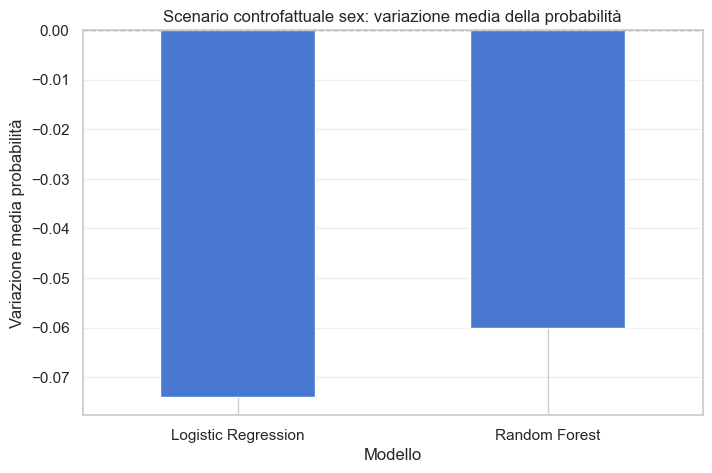

In [182]:
sex_mean_plot = sex_cf_summary.set_index("Modello")["Variazione media probabilità"]

ax = sex_mean_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Scenario controfattuale sex: variazione media della probabilità")
plt.xlabel("Modello")
plt.ylabel("Variazione media probabilità")
plt.axhline(0, linestyle="--", linewidth=1)
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

L’analisi controfattuale relativa alla variabile `sex` è stata condotta modificando il valore da `Male` a `Female` per i soggetti del test set appartenenti originariamente al gruppo Male. L’analisi ha coinvolto 1488 osservazioni, mantenendo invariate tutte le altre caratteristiche.

I risultati mostrano che la modifica della variabile `sex` produce una diminuzione della probabilità stimata di recidiva in entrambi i modelli. Nel caso della Logistic Regression, la variazione media della probabilità è pari a -0.074, mentre la variazione mediana è pari a -0.079. Ciò indica che, passando dallo scenario originale `Male` allo scenario controfattuale `Female`, il modello tende ad attribuire una probabilità di recidiva più bassa.

Anche la Random Forest mostra una diminuzione media della probabilità stimata, pari a -0.060, con una variazione mediana pari a -0.056. Tuttavia, rispetto alla Logistic Regression, la Random Forest presenta una maggiore quota di classi cambiate: 0.259 contro 0.110. Questo significa che il modello Random Forest modifica la classe finale prevista in circa il 25,9% dei casi, mentre la Logistic Regression la modifica nell’11,0% dei casi.

La differenza tra i due modelli suggerisce che la Logistic Regression produce una riduzione più regolare della probabilità stimata, mentre la Random Forest risulta più sensibile e instabile rispetto alla modifica della variabile `sex`. Questo è confermato anche dall’ampiezza delle variazioni osservate nella Random Forest, che presenta una variazione minima pari a -0.705 e una variazione massima pari a 0.796.

Nel complesso, l’analisi controfattuale mostra che la variabile `sex` incide sulle previsioni dei modelli. La modifica da `Male` a `Female` tende generalmente a ridurre la probabilità stimata di recidiva, indicando una sensibilità dei modelli rispetto a questa variabile. Anche in questo caso, il risultato deve essere interpretato come un’analisi esplorativa di sensibilità e non come una prova causale definitiva.

___
## tabella riassuntiva

In [186]:
counterfactual_summary = pd.concat(
    [race_cf_summary, sex_cf_summary],
    ignore_index=True
)

display(counterfactual_summary)

,Scenario,Modello,N osservazioni modificate,Quota classi cambiate,Variazione media probabilità,Variazione mediana probabilità,Variazione minima probabilità,Variazione massima probabilità
0,African-American -> Caucasian,Logistic Regression,941,0.045,0.020,0.021,0.002,0.024
1,African-American -> Caucasian,Random Forest,941,0.252,0.008,0.000,-0.808,0.750
2,Male -> Female,Logistic Regression,1488,0.110,-0.074,-0.079,-0.092,-0.007
3,Male -> Female,Random Forest,1488,0.259,-0.060,-0.056,-0.705,0.796


In [187]:
counterfactual_summary.style.background_gradient(
    subset=[
        "Quota classi cambiate",
        "Variazione media probabilità",
        "Variazione mediana probabilità",
        "Variazione minima probabilità",
        "Variazione massima probabilità"
    ],
    cmap="coolwarm"
).format({
    "Quota classi cambiate": "{:.3f}",
    "Variazione media probabilità": "{:.3f}",
    "Variazione mediana probabilità": "{:.3f}",
    "Variazione minima probabilità": "{:.3f}",
    "Variazione massima probabilità": "{:.3f}"
})

,Scenario,Modello,N osservazioni modificate,Quota classi cambiate,Variazione media probabilità,Variazione mediana probabilità,Variazione minima probabilità,Variazione massima probabilità
0,African-American -> Caucasian,Logistic Regression,941,0.045,0.020,0.021,0.002,0.024
1,African-American -> Caucasian,Random Forest,941,0.252,0.008,0.000,-0.808,0.750
2,Male -> Female,Logistic Regression,1488,0.110,-0.074,-0.079,-0.092,-0.007
3,Male -> Female,Random Forest,1488,0.259,-0.060,-0.056,-0.705,0.796
